In [1]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

# PART 1: PHOTOVOLTAIC POWER

In [2]:
#Load data from csv
load_file_pv = pd.read_csv('pv_student.csv',sep=',',index_col=0, parse_dates= ["Datetime"])

load_file_pv.index = pd.to_datetime(load_file_pv.index, utc=True).tz_convert("Europe/Berlin")
load_file_pv["Simulation"] = pd.to_numeric(load_file_pv["Simulation"], errors="coerce")
load_file_pv["Actuals"]    = pd.to_numeric(load_file_pv["Actuals"],    errors="coerce")

load_file_pv.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26280 entries, 2013-01-01 01:00:00+01:00 to 2016-01-01 00:00:00+01:00
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Simulation  26280 non-null  float64
 1   Actuals     26280 non-null  float64
dtypes: float64(2)
memory usage: 615.9 KB


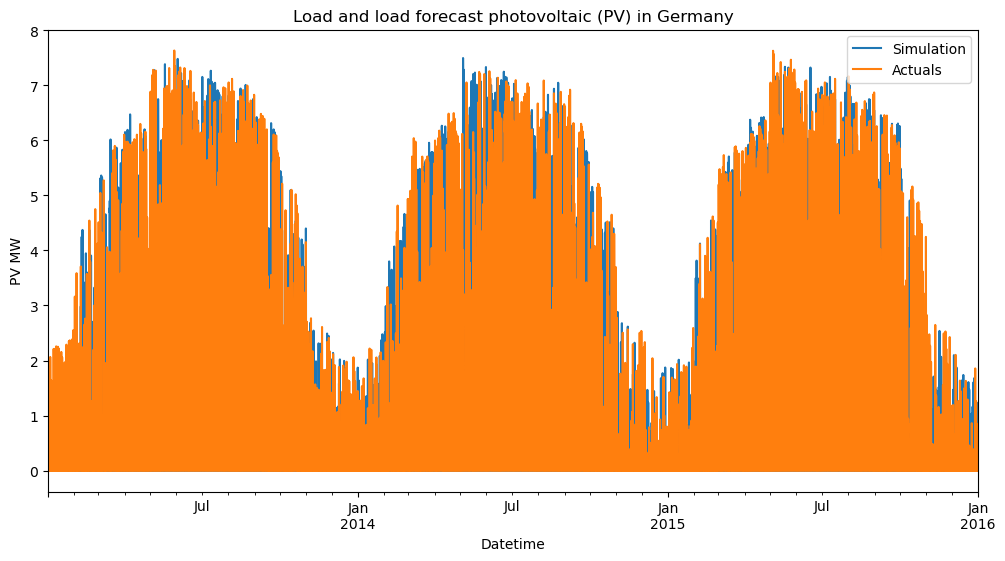

In [3]:
load_file_pv.plot(title='Load and load forecast photovoltaic (PV) in Germany',
                     figsize=(12,6),
                     ylabel='PV MW');

In [4]:
# =========================
#  have a quick look at the data
# =========================
print(load_file_pv.head(10))
print(load_file_pv.tail(10))

load_file_pv["Simulation"].describe()
load_file_pv["Actuals"].describe()

                           Simulation   Actuals
Datetime                                       
2013-01-01 01:00:00+01:00    0.000000  0.000000
2013-01-01 02:00:00+01:00    0.000000  0.000000
2013-01-01 03:00:00+01:00    0.000000  0.000000
2013-01-01 04:00:00+01:00    0.000000  0.000000
2013-01-01 05:00:00+01:00    0.000000  0.000000
2013-01-01 06:00:00+01:00    0.000000  0.000000
2013-01-01 07:00:00+01:00    0.000000  0.000000
2013-01-01 08:00:00+01:00    0.020461  0.011578
2013-01-01 09:00:00+01:00    0.112875  0.086446
2013-01-01 10:00:00+01:00    0.192405  0.146997
                           Simulation   Actuals
Datetime                                       
2015-12-31 15:00:00+01:00    0.534338  0.008652
2015-12-31 16:00:00+01:00    0.035740  0.000760
2015-12-31 17:00:00+01:00    0.001007  0.000253
2015-12-31 18:00:00+01:00    0.000512  0.000000
2015-12-31 19:00:00+01:00    0.000000  0.000000
2015-12-31 20:00:00+01:00    0.000000  0.000000
2015-12-31 21:00:00+01:00    0.000000  0

count    26280.000000
mean         1.065706
std          1.782656
min          0.000000
25%          0.000000
50%          0.029696
75%          1.369133
max          7.635100
Name: Actuals, dtype: float64

In [5]:
# Make working copy

df_pv = pd.read_csv('pv_student.csv', sep=',', parse_dates=["Datetime"])
df_pv = df_pv.set_index("Datetime")
df_pv.index = pd.to_datetime(df_pv.index, utc=True).tz_convert("Europe/Berlin")

# =========================
# Construct error series
# =========================
df_pv["error"] = df_pv["Simulation"] - df_pv["Actuals"]

print(df_pv["error"].head(10))

Datetime
2013-01-01 01:00:00+01:00    0.000000
2013-01-01 02:00:00+01:00    0.000000
2013-01-01 03:00:00+01:00    0.000000
2013-01-01 04:00:00+01:00    0.000000
2013-01-01 05:00:00+01:00    0.000000
2013-01-01 06:00:00+01:00    0.000000
2013-01-01 07:00:00+01:00    0.000000
2013-01-01 08:00:00+01:00    0.008883
2013-01-01 09:00:00+01:00    0.026429
2013-01-01 10:00:00+01:00    0.045408
Name: error, dtype: float64


In [6]:
# =========================
#  Comprehensive sanity checks
# =========================
print("=" * 60)
print("1. Data shape")
print(df_pv.shape)

print("\n2. Time range")
print(df_pv.index.min())
print(df_pv.index.max())

print("\n3. Missing values")
print(df_pv.isna().sum())

print("\n4. Daily observations")
print(df_pv.groupby(df_pv.index.date).size().value_counts().sort_index())

print("\n5. Timezone")
print(df_pv.index.tz)


print("\n6. Value range reasonableness")
print(df_pv.describe())


print("\n8. Duplicate timestamps")
print(f"Number of duplicate timestamps: {df_pv.index.duplicated().sum()}")

1. Data shape
(26280, 3)

2. Time range
2013-01-01 01:00:00+01:00
2016-01-01 00:00:00+01:00

3. Missing values
Simulation    0
Actuals       0
error         0
dtype: int64

4. Daily observations
1        1
23       4
24    1088
25       3
Name: count, dtype: int64

5. Timezone
Europe/Berlin

6. Value range reasonableness
         Simulation       Actuals         error
count  26280.000000  26280.000000  26280.000000
mean       1.025447      1.065706     -0.040259
std        1.739334      1.782656      1.174800
min        0.000000      0.000000     -7.207433
25%        0.000000      0.000000     -0.019441
50%        0.027290      0.029696      0.000000
75%        1.253535      1.369133      0.003203
max        7.498540      7.635100      6.681336

8. Duplicate timestamps
Number of duplicate timestamps: 0


Daily MAE summary:
count    1096.000000
mean        0.543732
std         0.427586
min         0.000000
25%         0.207320
50%         0.430635
75%         0.777513
max         2.269733
Name: error, dtype: float64

Top 10 largest daily MAE:
2014-05-20    2.269733
2013-06-10    2.258925
2014-05-05    2.214742
2013-05-31    2.121469
2014-07-08    2.113167
2014-07-10    2.070041
2013-07-29    1.957664
2013-08-21    1.952909
2014-07-12    1.947277
2013-05-29    1.931487
Name: error, dtype: float64


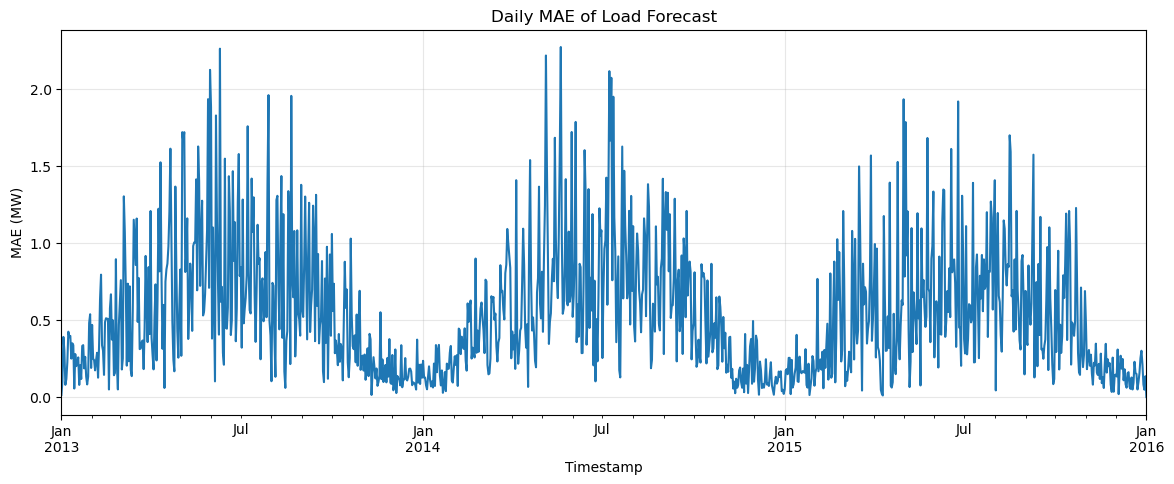

In [7]:
# =========================
# Daily MAE
# =========================
daily_mae = df_pv.groupby(df_pv.index.date)["error"].apply(lambda x: x.abs().mean())
daily_mae.index = pd.to_datetime(daily_mae.index)
daily_mae = daily_mae.dropna()


print("Daily MAE summary:")
print(daily_mae.describe())

print("\nTop 10 largest daily MAE:")
print(daily_mae.nlargest(10))

# =========================
#  Plot daily MAE
# =========================
plt.figure(figsize=(14, 5))
daily_mae.plot()
plt.title("Daily MAE of Load Forecast")
plt.ylabel("MAE (MW)")
plt.xlabel("Timestamp")
plt.grid(True, alpha=0.3)
plt.show()

Higher MAE in summer seasons (due to more sun and less certainty).

Mean error (bias): -0.0403
Mean absolute error（MAE）: 0.5441


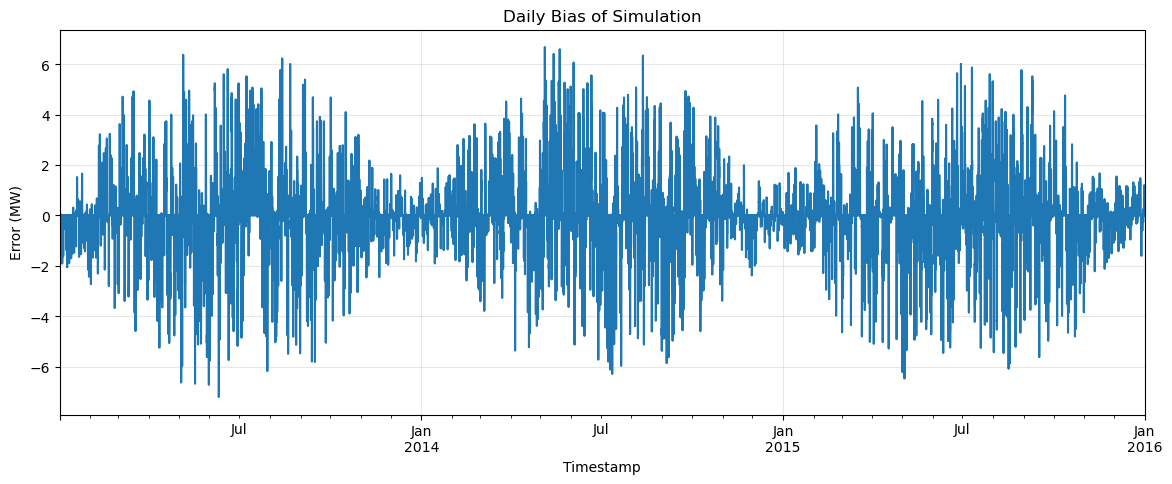

Error volatility diagnostics
Standard deviation of error: 1.1748
Variance of error: 1.3802
MAPE: 113.52%
RMSE: 1.1755 MW


In [8]:
# =========================
#  daily bias 
# =========================
daily_bias = df_pv.groupby(df_pv.index.date)["error"].mean()
daily_bias.index = pd.to_datetime(daily_bias.index)
daily_bias = daily_bias.dropna()


mean_error = df_pv["error"].mean()
mean_abs_error = df_pv["error"].abs().mean()


print(f"Mean error (bias): {mean_error:.4f}")
print(f"Mean absolute error（MAE）: {mean_abs_error:.4f}")

plt.figure(figsize=(14, 5))
df_pv["error"].plot()
plt.title("Daily Bias of Simulation")
plt.ylabel("Error (MW)")
plt.xlabel("Timestamp")
plt.grid(True, alpha=0.3)
plt.show()

# =========================
#  Error volatility
# =========================
print("Error volatility diagnostics")
print(f"Standard deviation of error: {df_pv['error'].std():.4f}")
print(f"Variance of error: {df_pv['error'].var():.4f}")

# =========================
#  MAPE and RMSE
# =========================
#for only cells where actuals are higher than zero, in daytime hours
nz_actuals= df_pv["Actuals"]> 0.01
mape = (df_pv['error'].abs() / df_pv.loc[nz_actuals, "Actuals"]).mean() * 100 
print(f"MAPE: {mape:.2f}%")

rmse = np.sqrt((df_pv['error'] ** 2).mean())
print(f"RMSE: {rmse:.4f} MW")

Simulation overestimates (bias =-0.04) by predicting more than real. Let´s see the MAPE by hours

In [9]:
# To observe the MAPE by hours per day to find weaknesses
df_analysis = df_pv.loc[nz_actuals].copy()
df_analysis["rel_error"] = (df_analysis["error"].abs() / df_analysis["Actuals"]) * 100
df_analysis["hour"] = df_analysis.index.hour
print("MAPE by hours per day:")
print(df_analysis.groupby("hour")["rel_error"].mean().round(1))

MAPE by hours per day:
hour
5      59.2
6     119.3
7     127.6
8     129.8
9     141.0
10    128.1
11    114.4
12    111.0
13    115.6
14    117.2
15    111.3
16    100.8
17    105.3
18     93.0
19     86.7
20     80.4
21     45.3
Name: rel_error, dtype: float64


Sunrise time (5-7h): 59-130%
Noon (8-15h): 110-140%
Evening (16-21h): 45-100%
Model fails when day starts, gets stabilized during the end of day

##TO CONSULT PV_SOLAR WITH XIN

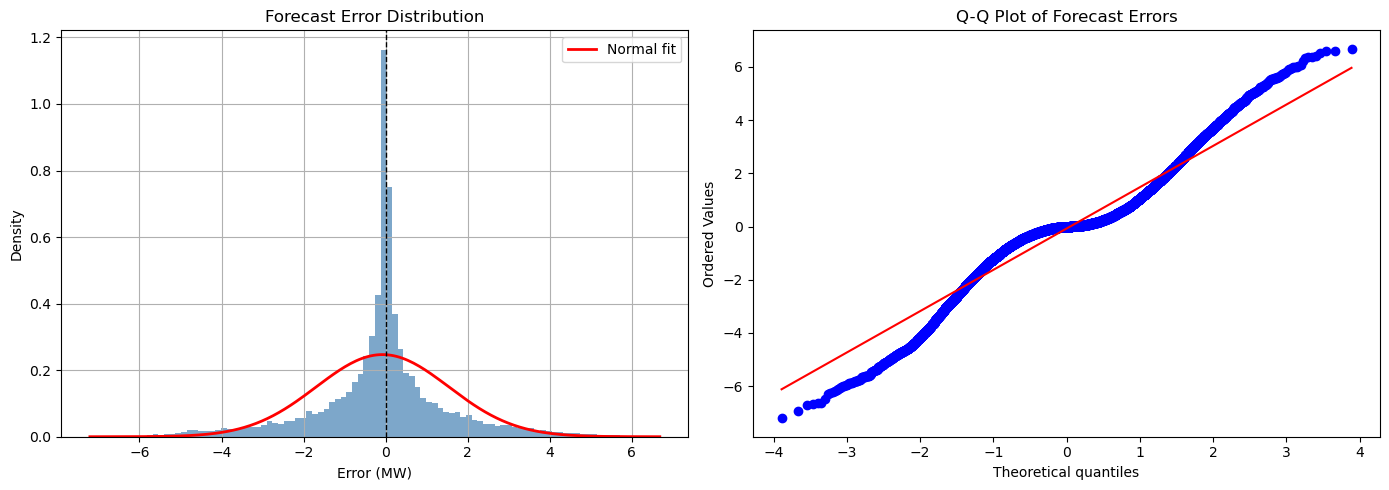

Skewness: -0.1572
Kurtosis: 2.4229


In [10]:
# =========================
#  error distribution analysis 
# =========================
"""TO CONSULTS PV_SOLAR WITH XIN (>0.01 OR WE GET RID OF HOURS, ONLY 6-20 OR 5-21)"""
import scipy.stats as stats

#Let´s filter only with hours with real generation
nz_values = (df_pv["Actuals"] > 0.01) | (df_pv["Simulation"] > 0.01)
df_solar = df_pv[nz_values].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# histogram + normal fit
ax1 = axes[0]
df_solar['error'].hist(bins=100, ax=ax1, density=True, alpha=0.7, color='steelblue')
mu, std = stats.norm.fit(df_solar['error'])
x = np.linspace(df_solar['error'].min(), df_solar['error'].max(), 200)
ax1.plot(x, stats.norm.pdf(x, mu, std), 'r-', linewidth=2, label='Normal fit')
ax1.axvline(0, color='black', linestyle='--', linewidth=1)
ax1.set_title('Forecast Error Distribution')
ax1.set_xlabel('Error (MW)')
ax1.set_ylabel('Density')
ax1.legend()

# ：QQ plot
ax2 = axes[1]
stats.probplot(df_solar['error'], dist="norm", plot=ax2)
ax2.set_title('Q-Q Plot of Forecast Errors')

plt.tight_layout()
plt.show()

# statistics on raw error(15min intervals)
print(f"Skewness: {df_solar['error'].skew():.4f}")
print(f"Kurtosis: {df_solar['error'].kurtosis():.4f}")

<Figure size 1200x500 with 0 Axes>

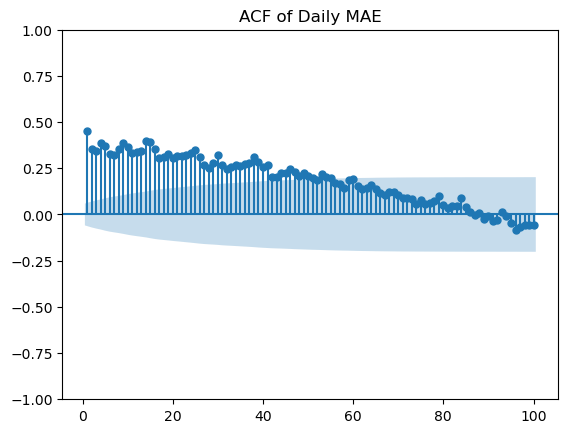

    lb_stat  lb_pvalue
7  1.04e+03  5.26e-220
14 2.05e+03   0.00e+00
20 2.79e+03   0.00e+00


In [11]:
# =========================
# Autocorrelation check
# =========================

import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox

plt.figure(figsize=(12, 5))
plot_acf(daily_mae, lags=100,zero = False)
plt.title("ACF of Daily MAE")
plt.show()


pd.set_option('display.float_format', '{:.2e}'.format)
result = acorr_ljungbox(daily_mae, lags=[7, 14, 20], return_df=True)
print(result)

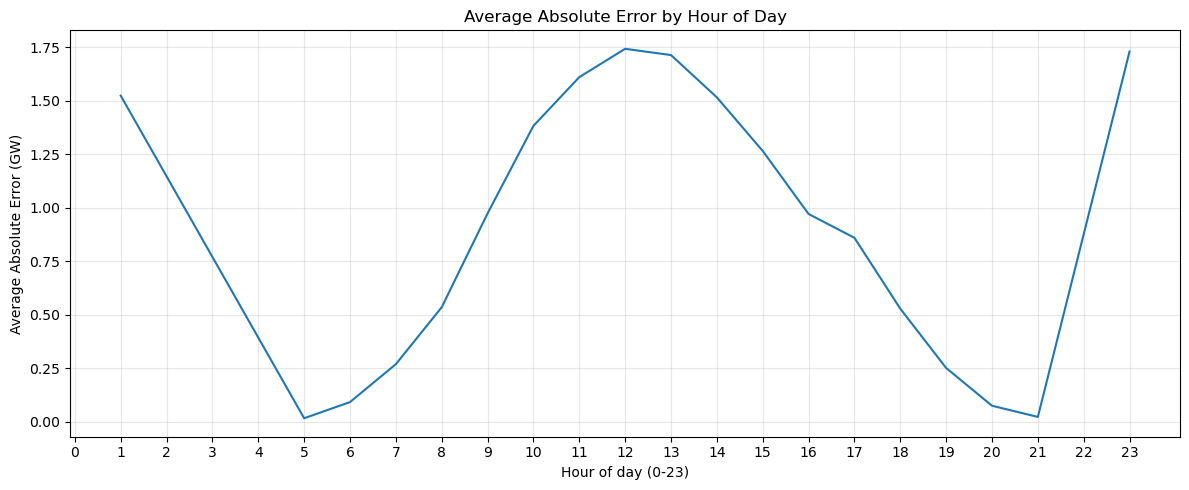

In [12]:
# =========================
#  Intraday error pattern
# =========================
intraday_slot = df_solar.index.hour
intraday_mae = df_solar.groupby(intraday_slot)["error"].apply(lambda x: x.abs().mean())

plt.figure(figsize=(12, 5))
intraday_mae.plot()
plt.title("Average Absolute Error by Hour of Day")
plt.xlabel("Hour of day (0-23)")
plt.ylabel("Average Absolute Error (GW)")
plt.xticks(range(24))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [13]:
# =========================
# yearly statistics table
# =========================

yearly_stats = df_solar.groupby(df_solar.index.year).apply(
    lambda x: pd.Series({
        'MAE': x['error'].abs().mean(),
        'RMSE': np.sqrt((x['error']**2).mean()),
        'Bias': x['error'].mean(),
        'MAPE (%)': (x.loc[x['Actuals'] > 0.05, 'error'].abs() / 
                     x.loc[x['Actuals'] > 0.05, 'Actuals']).mean() * 100,
        'RMSE/MAE': np.sqrt((x['error']**2).mean()) / x['error'].abs().mean()
    })
)

yearly_stats['RMSE/MAE'] = yearly_stats['RMSE'] / yearly_stats['MAE']
pd.set_option('display.float_format', '{:.3f}'.format)
print(yearly_stats.round(3))

print()

# =========================
# kruskal-wallis test for yearly MAE
# =========================

from scipy.stats import kruskal

mae_2013 = daily_mae[daily_mae.index.year == 2013]
mae_2014 = daily_mae[daily_mae.index.year == 2014]
mae_2015 = daily_mae[daily_mae.index.year == 2015]

stat, p = kruskal(mae_2013, mae_2014, mae_2015)

print(f"Kruskal-Wallis Test (2013 vs 2014 vs 2015)")
print(f"  H-statistic: {stat:.3f}")
print(f"  p-value:     {p:.3f}")
print(f"  Conclusion:  {'Significant difference between years (p < 0.05)' if p < 0.05 else 'No significant difference between years (p >= 0.05)'}")

           MAE  RMSE   Bias  MAPE (%)  RMSE/MAE
Datetime                                       
2013     1.076 1.684 -0.133   103.879     1.565
2014     1.062 1.645  0.060   118.554     1.549
2015     0.954 1.520 -0.155    98.222     1.593

Kruskal-Wallis Test (2013 vs 2014 vs 2015)
  H-statistic: 4.517
  p-value:     0.104
  Conclusion:  No significant difference between years (p >= 0.05)


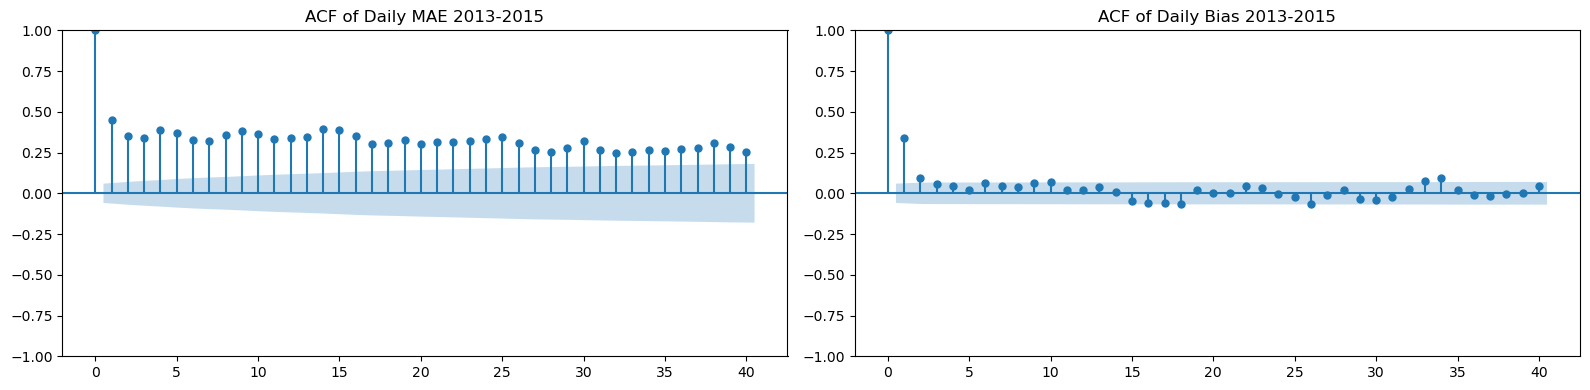

Ljung-Box test for stable period MAE
    lb_stat  lb_pvalue
7  1035.036      0.000
14 2037.614      0.000
20 2777.139      0.000

Ljung-Box test for stable period Bias
    lb_stat  lb_pvalue
7   147.550      0.000
14  161.696      0.000
20  177.106      0.000


In [14]:
# =========================
#  stable period 2013-2015 examination
# =========================
 
stable_peroid_mae  = daily_mae['2013':'2015'].dropna()
stable_peroid_bias = daily_bias['2013':'2015'].dropna()

# 5 ACF / serial dependence

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plot_acf(stable_peroid_mae, lags=40, ax=axes[0])
axes[0].set_title("ACF of Daily MAE 2013-2015")

plot_acf(stable_peroid_bias, lags=40, ax=axes[1])
axes[1].set_title("ACF of Daily Bias 2013-2015")

plt.tight_layout()
plt.show()

# Ljung-Box
lb_mae = acorr_ljungbox(stable_peroid_mae, lags=[7, 14, 20], return_df=True)
lb_bias = acorr_ljungbox(stable_peroid_bias, lags=[7, 14, 20], return_df=True)

print("Ljung-Box test for stable period MAE")
print(lb_mae)
print("\nLjung-Box test for stable period Bias")
print(lb_bias)

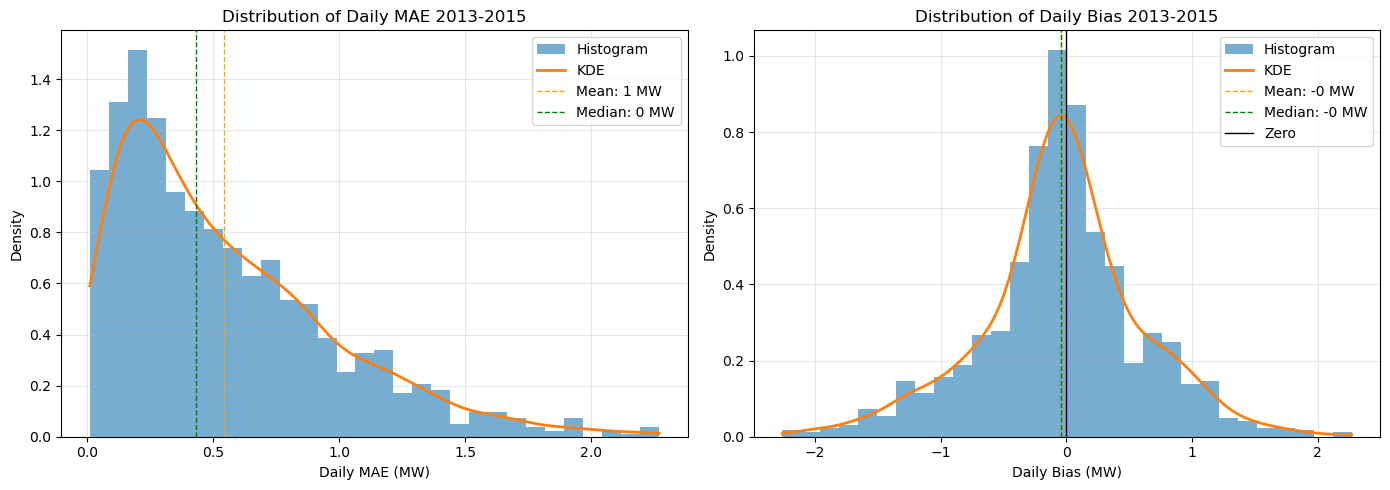

In [15]:
# =========================
# 2013-2015 error distribution of daily MAE and Bias
# =========================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- MAE Distribution ---
ax = axes[0]
ax.hist(stable_peroid_mae.dropna(), bins=30, density=True, alpha=0.6, label='Histogram')
kde = stats.gaussian_kde(stable_peroid_mae.dropna())
x = np.linspace(stable_peroid_mae.min(), stable_peroid_mae.max(), 300)
ax.plot(x, kde(x), linewidth=2, label='KDE')
ax.axvline(stable_peroid_mae.mean(), linestyle='--', color='orange', linewidth=1, label=f'Mean: {stable_peroid_mae.mean():.0f} MW')
ax.axvline(stable_peroid_mae.median(), linestyle='--', color='green', linewidth=1, label=f'Median: {stable_peroid_mae.median():.0f} MW')
ax.set_title("Distribution of Daily MAE 2013-2015")
ax.set_xlabel("Daily MAE (MW)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)

# --- Bias Distribution ---
ax = axes[1]
ax.hist(stable_peroid_bias.dropna(), bins=30, density=True, alpha=0.6, label='Histogram')
kde = stats.gaussian_kde(stable_peroid_bias.dropna())
x = np.linspace(stable_peroid_bias.min(), stable_peroid_bias.max(), 300)
ax.plot(x, kde(x), linewidth=2, label='KDE')
ax.axvline(stable_peroid_bias.mean(), linestyle='--', color='orange', linewidth=1, label=f'Mean: {stable_peroid_bias.mean():.0f} MW')
ax.axvline(stable_peroid_bias.median(), linestyle='--', color='green', linewidth=1, label=f'Median: {stable_peroid_bias.median():.0f} MW')
ax.axvline(0, linestyle='-', color='black', linewidth=1, label='Zero')
ax.set_title("Distribution of Daily Bias 2013-2015")
ax.set_xlabel("Daily Bias (MW)")
ax.set_ylabel("Density")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [16]:
# Skewness and kurtosis for stable period MAE and Bias
from scipy.stats import skew, kurtosis

print("Stable Period MAE skewness :", skew(stable_peroid_mae))
print("Stable Period MAE kurtosis :", kurtosis(stable_peroid_mae, fisher=True))

print("Stable Period Bias skewness:", skew(stable_peroid_bias))
print("Stable Period Bias kurtosis:", kurtosis(stable_peroid_bias, fisher=True))

Stable Period MAE skewness : 1.1559382400435012
Stable Period MAE kurtosis : 1.1301153350131976
Stable Period Bias skewness: -0.11756327062988886
Stable Period Bias kurtosis: 0.903336583523358


In [17]:
# =========================
#  Yearly  and Quarterly summary table 2013-2015
# =========================
import pandas as pd

stable_peroid_df = pd.DataFrame({
    "MAE": stable_peroid_mae,
    "Bias": stable_peroid_bias
})

pd.set_option('display.float_format', '{:.3f}'.format)
# Annual statistics
stable_peroid_df["Year"] = stable_peroid_df.index.year
print("=== Annual Summary ===")
print(stable_peroid_df.groupby("Year")[["MAE", "Bias"]].agg(["mean", "median", "std"]).round(1))
print()

# Quarterly statistics (appendix)
stable_peroid_df["Quarter"] = stable_peroid_df.index.to_period("Q")
print("=== Quarterly Summary ===")
print(stable_peroid_df.groupby("Quarter")[["MAE", "Bias"]].agg(["mean", "std"]).round(1))

=== Annual Summary ===
       MAE                Bias             
      mean median   std   mean median   std
Year                                       
2013 0.600  0.400 0.400 -0.100 -0.100 0.700
2014 0.600  0.500 0.400  0.000  0.000 0.700
2015 0.500  0.400 0.400 -0.100 -0.100 0.600

=== Quarterly Summary ===
          MAE         Bias      
         mean   std   mean   std
Quarter                         
2013Q1  0.400 0.300 -0.000 0.500
2013Q2  0.900 0.500 -0.300 0.900
2013Q3  0.700 0.400  0.000 0.800
2013Q4  0.300 0.200 -0.000 0.300
2014Q1  0.400 0.300  0.100 0.400
2014Q2  0.800 0.500  0.200 0.800
2014Q3  0.800 0.400 -0.100 0.900
2014Q4  0.300 0.200 -0.000 0.300
2015Q1  0.400 0.300 -0.000 0.500
2015Q2  0.700 0.400 -0.200 0.700
2015Q3  0.700 0.400 -0.000 0.700
2015Q4  0.300 0.300 -0.100 0.400


In [18]:
# =========================
#  seasonal summary table 2013-2015
# =========================

#  Assign season labels

def month_to_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

season_order = ["Winter", "Spring", "Summer", "Autumn"]

stable_peroid_df["Month"] = stable_peroid_df.index.month
stable_peroid_df["Season"] = stable_peroid_df["Month"].apply(month_to_season)
stable_peroid_df["Season"] = pd.Categorical(
    stable_peroid_df["Season"],
    categories=season_order,
    ordered=True
)

# -----------------------------
#  Seasonal summary table
# -----------------------------
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

seasonal_summary = stable_peroid_df.groupby("Season", observed=False)[["MAE", "Bias"]].agg(
    ["mean", "median", "std", iqr]
)

print("Seasonal summary table:")
print(seasonal_summary)


# -----------------------------
# 5. Kruskal–Wallis tests
# -----------------------------
mae_groups = [
    stable_peroid_df.loc[stable_peroid_df["Season"] == s, "MAE"].dropna()
    for s in season_order
]
bias_groups = [
    stable_peroid_df.loc[stable_peroid_df["Season"] == s, "Bias"].dropna()
    for s in season_order
]

kw_mae = kruskal(*mae_groups)
kw_bias = kruskal(*bias_groups)

print("\nKruskal–Wallis test for MAE across seasons:")
print(kw_mae)

print("\nKruskal–Wallis test for Bias across seasons:")
print(kw_bias)

Seasonal summary table:
         MAE                      Bias                   
        mean median   std   iqr   mean median   std   iqr
Season                                                   
Winter 0.227  0.177 0.182 0.200 -0.011 -0.025 0.281 0.319
Spring 0.697  0.620 0.446 0.563 -0.080 -0.071 0.779 1.011
Summer 0.794  0.704 0.441 0.627 -0.000  0.047 0.839 1.228
Autumn 0.451  0.352 0.331 0.455 -0.070 -0.073 0.518 0.517

Kruskal–Wallis test for MAE across seasons:
KruskalResult(statistic=np.float64(358.9893088799445), pvalue=np.float64(1.6871263942352742e-77))

Kruskal–Wallis test for Bias across seasons:
KruskalResult(statistic=np.float64(4.940415742546975), pvalue=np.float64(0.17621255285791804))


YEARLY SUMMARY (2013–2014)
       MAE                      Bias                   
      mean median   std   iqr   mean median   std   iqr
Year                                                   
2013 0.600  0.400 0.400 0.600 -0.100 -0.100 0.700 0.700
2014 0.600  0.500 0.400 0.600  0.000  0.000 0.700 0.700

SEASONAL SUMMARY (2013–2014)
         MAE                      Bias                   
        mean median   std   iqr   mean median   std   iqr
Season                                                   
Winter 0.200  0.200 0.200 0.200 -0.000 -0.000 0.300 0.300
Spring 0.700  0.700 0.400 0.500 -0.000 -0.000 0.800 1.200
Summer 0.800  0.700 0.500 0.600  0.000  0.100 0.900 1.300
Autumn 0.500  0.400 0.300 0.500 -0.000 -0.100 0.500 0.600

BIAS SIGN BY SEASON
        Mean (MW)  Median (MW)  % Days Positive  % Days Negative
Season                                                          
Winter     -0.000       -0.000           45.000           55.000
Spring     -0.000       -0.000           

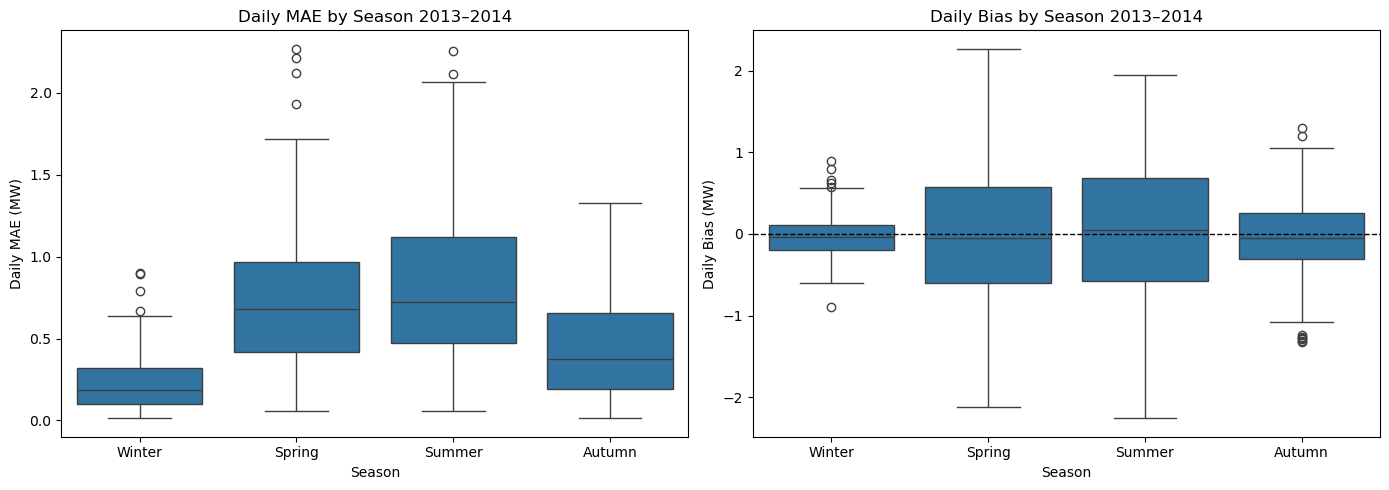

In [19]:
# =========================
# examnation of  2013-2014 
# =========================

# ─── 1.  Phase I baseline: 2013–2014 ───────────────────────
baseline_mae = daily_mae.loc['2013-01-01':'2014-12-31']
baseline_bias = daily_bias.loc['2013-01-01':'2014-12-31']

# ─── 2.  DataFrame ──────────────────────────────────────────
baseline_df = pd.DataFrame({
    "MAE": baseline_mae,
    "Bias": baseline_bias
}).copy()

baseline_df = baseline_df.dropna(subset=["MAE", "Bias"]).copy()


baseline_df["Year"] = baseline_df.index.year
baseline_df["Month"] = baseline_df.index.month
baseline_df["Season"] = baseline_df["Month"].apply(month_to_season)

season_order = ["Winter", "Spring", "Summer", "Autumn"]
baseline_df["Season"] = pd.Categorical(
    baseline_df["Season"],
    categories=season_order,
    ordered=True
)

# ─── 3. IQR function ────────────────────────────────────────────
def iqr(x):
    return x.quantile(0.75) - x.quantile(0.25)

# ─── 4. Yearly Summary ──────────────────────────────────────────
print("=" * 60)
print("YEARLY SUMMARY (2013–2014)")
print("=" * 60)

yearly = baseline_df.groupby("Year")[["MAE", "Bias"]].agg(
    ["mean", "median", "std", iqr]
).round(1)
print(yearly)

# ─── 5. Seasonal Summary ────────────────────────────────────────
print("\n" + "=" * 60)
print("SEASONAL SUMMARY (2013–2014)")
print("=" * 60)

seasonal = baseline_df.groupby("Season")[["MAE", "Bias"]].agg(
    ["mean", "median", "std", iqr]
).round(1)
print(seasonal)

# ─── 6. Bias Sign Table ─────────────────────────────────────────
print("\n" + "=" * 60)
print("BIAS SIGN BY SEASON")
print("=" * 60)

sign_table = baseline_df.groupby("Season")["Bias"].agg(
    mean="mean",
    median="median",
    pct_pos=lambda x: (x > 0).mean() * 100,
    pct_neg=lambda x: (x < 0).mean() * 100,
).round(1)

sign_table.columns = ["Mean (MW)", "Median (MW)", "% Days Positive", "% Days Negative"]
print(sign_table)

# ─── 7. Kruskal–Wallis Tests ────────────────────────────────────
print("\n" + "=" * 60)
print("KRUSKAL–WALLIS TEST (2013–2014)")
print("=" * 60)

mae_groups = [
    baseline_df.loc[baseline_df["Season"] == s, "MAE"].dropna()
    for s in season_order
]
bias_groups = [
    baseline_df.loc[baseline_df["Season"] == s, "Bias"].dropna()
    for s in season_order
]

kw_mae = kruskal(*mae_groups)
kw_bias = kruskal(*bias_groups)

print(f"MAE  — H = {kw_mae.statistic:.3f}, p = {kw_mae.pvalue:.2e}")
print(f"Bias — H = {kw_bias.statistic:.3f}, p = {kw_bias.pvalue:.2e}")

# -----------------------------
# Boxplots by season
# -----------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=baseline_df, x="Season", y="MAE", order=season_order, ax=axes[0])
axes[0].set_title("Daily MAE by Season 2013–2014")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("Daily MAE (MW)")

sns.boxplot(data=baseline_df, x="Season", y="Bias", order=season_order, ax=axes[1])
axes[1].set_title("Daily Bias by Season 2013–2014")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Daily Bias (MW)")
axes[1].axhline(0, linestyle="--", linewidth=1, color="black")
plt.savefig("boxplot_season.png", dpi=300, bbox_inches="tight")

plt.tight_layout()
plt.show()


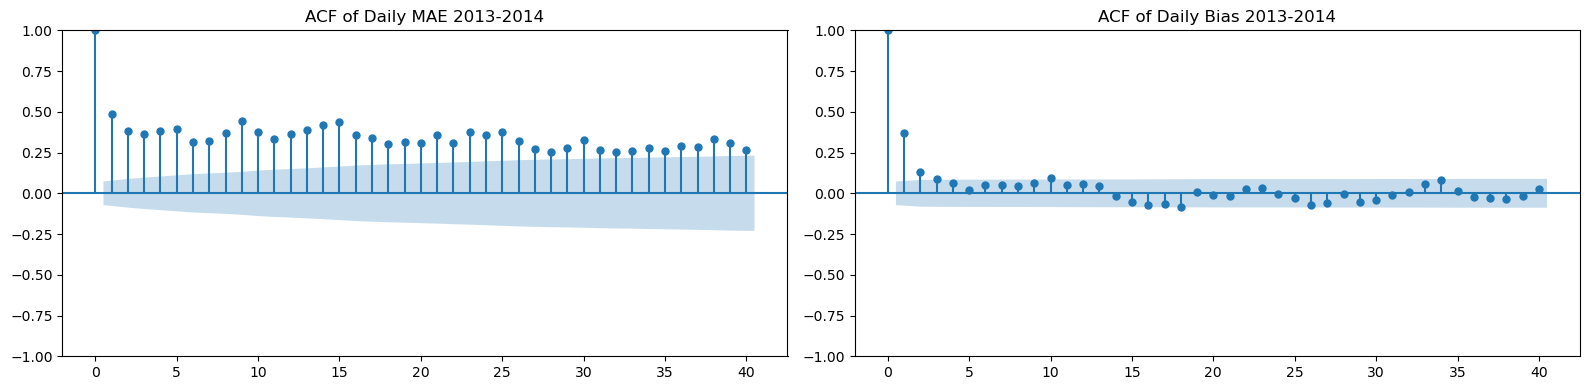

Ljung-Box test for baseline MAE
    lb_stat  lb_pvalue
7   749.081      0.000
14 1530.610      0.000
20 2068.236      0.000

Ljung-Box test for baseline Bias
    lb_stat  lb_pvalue
7   125.679      0.000
14  143.666      0.000
20  158.449      0.000


In [20]:
#  ACF / serial dependence baseline 2013–2014

baseline_mae = daily_mae.loc['2013-01-01':'2014-12-31'].dropna()
baseline_bias = daily_bias.loc['2013-01-01':'2014-12-31'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 4))

plot_acf(baseline_mae, lags=40, ax=axes[0])
axes[0].set_title("ACF of Daily MAE 2013-2014")

plot_acf(baseline_bias, lags=40, ax=axes[1])
axes[1].set_title("ACF of Daily Bias 2013-2014")

plt.tight_layout()
plt.show()

# Ljung-Box
lb_mae = acorr_ljungbox(baseline_mae, lags=[7, 14, 20], return_df=True)
lb_bias = acorr_ljungbox(baseline_bias, lags=[7, 14, 20], return_df=True)

print("Ljung-Box test for baseline MAE")
print(lb_mae)
print("\nLjung-Box test for baseline Bias")
print(lb_bias)

In [21]:
# =========================
# seasonal Bias Centering
# =========================
# Seasonal means and medians for Bias in Phase I
bias_season_mean = baseline_df.groupby("Season")["Bias"].mean()
bias_season_median = baseline_df.groupby("Season")["Bias"].median()

# Mean-centered Bias
baseline_df["Bias_centered_mean"] = baseline_df.apply(
    lambda row: row["Bias"] - bias_season_mean.loc[row["Season"]],
    axis=1
)

# Median-centered Bias
baseline_df["Bias_centered_median"] = baseline_df.apply(
    lambda row: row["Bias"] - bias_season_median.loc[row["Season"]],
    axis=1
)

# Check seasonal summaries after centering
centered_mean_summary = baseline_df.groupby("Season")["Bias_centered_mean"].agg(
    ["std"]
).round(1)

centered_median_summary = baseline_df.groupby("Season")["Bias_centered_median"].agg(
    ["std"]
).round(1)

print("Mean-centered Bias summary by season:")
print(centered_mean_summary)

print("\nMedian-centered Bias summary by season:")
print(centered_median_summary)

Mean-centered Bias summary by season:
         std
Season      
Winter 0.300
Spring 0.800
Summer 0.900
Autumn 0.500

Median-centered Bias summary by season:
         std
Season      
Winter 0.300
Spring 0.800
Summer 0.900
Autumn 0.500


In [22]:
from scipy.stats import kruskal, levene

season_order = ["Winter", "Spring", "Summer", "Autumn"]

# KW test after mean-centering
groups_mean = [
    baseline_df.loc[baseline_df["Season"] == s, "Bias_centered_mean"].dropna()
    for s in season_order
]
kw_after_mean = kruskal(*groups_mean)

# KW test after median-centering
groups_median = [
    baseline_df.loc[baseline_df["Season"] == s, "Bias_centered_median"].dropna()
    for s in season_order
]
kw_after_median = kruskal(*groups_median)

print("Kruskal-Wallis BEFORE centering: H = 134.783, p = 5.04e-29")
print(f"Kruskal-Wallis AFTER mean-centering:   H = {kw_after_mean.statistic:.3f}, p = {kw_after_mean.pvalue:.4f}")
print(f"Kruskal-Wallis AFTER median-centering: H = {kw_after_median.statistic:.3f}, p = {kw_after_median.pvalue:.4f}")

# Levene test：
levene_after = levene(*groups_mean)
print(f"\nLevene test after mean-centering: F = {levene_after.statistic:.3f}, p = {levene_after.pvalue:.4f}")

Kruskal-Wallis BEFORE centering: H = 134.783, p = 5.04e-29
Kruskal-Wallis AFTER mean-centering:   H = 0.546, p = 0.9087
Kruskal-Wallis AFTER median-centering: H = 0.258, p = 0.9678

Levene test after mean-centering: F = 58.788, p = 0.0000


In [23]:
# Season-specific std for scaling
bias_season_std = baseline_df.groupby("Season")["Bias"].std()

season_str = baseline_df["Season"].astype(str)

# Standardized Bias
baseline_df["Bias_standardized"] = (
    baseline_df["Bias"] - season_str.map(bias_season_mean)
) / season_str.map(bias_season_std)

# Verify
std_summary = baseline_df.groupby("Season")["Bias_standardized"].agg(
    ["mean", "std", "median"]
).round(3)
print("Standardized Bias summary by season:")
print(std_summary)

# KW and levene after standardization
groups_std = [
    baseline_df.loc[baseline_df["Season"] == s, "Bias_standardized"].dropna()
    for s in season_order
]
kw_std = kruskal(*groups_std)
levene_std = levene(*groups_std)

print(f"\nKruskal-Wallis after standardization: H = {kw_std.statistic:.3f}, p = {kw_std.pvalue:.4f}")
print(f"Levene after standardization: F = {levene_std.statistic:.3f}, p = {levene_std.pvalue:.4f}")

print()

# Brown–Forsythe test for MAE dispersion across seasons (MAE is right skewed, so median-based test is more robust)
mae_groups = [
    baseline_df.loc[baseline_df["Season"] == s, "MAE"].dropna()
    for s in season_order
]

bf_mae = levene(*mae_groups, center="median")

print(f"Brown–Forsythe test for MAE dispersion: F = {bf_mae.statistic:.3f}, p = {bf_mae.pvalue:.4f}")

Standardized Bias summary by season:
         mean   std  median
Season                     
Winter -0.000 1.000  -0.064
Spring -0.000 1.000  -0.045
Summer -0.000 1.000   0.053
Autumn -0.000 1.000  -0.007

Kruskal-Wallis after standardization: H = 0.423, p = 0.9355
Levene after standardization: F = 0.405, p = 0.7494

Brown–Forsythe test for MAE dispersion: F = 34.899, p = 0.0000


In [24]:
# correlation between daily MAE and Bias Pearson and Spearman （Appendix)
# 2013-2015 full period
daily_mae2 = daily_mae.copy()
daily_bias2 = daily_bias.copy()

daily_mae2.index = pd.to_datetime(daily_mae2.index)
daily_bias2.index = pd.to_datetime(daily_bias2.index)

daily_mae2.index = daily_mae2.index.normalize()
daily_bias2.index = daily_bias2.index.normalize()

tmp = pd.concat([daily_mae2, daily_bias2], axis=1)
tmp.columns = ["MAE", "Bias"]
tmp["AbsBias"] = tmp["Bias"].abs()

print(tmp[["MAE", "Bias", "AbsBias"]].corr(method="pearson"))
print(tmp[["MAE", "Bias", "AbsBias"]].corr(method="spearman"))


           MAE   Bias  AbsBias
MAE      1.000 -0.110    0.960
Bias    -0.110  1.000   -0.113
AbsBias  0.960 -0.113    1.000
           MAE   Bias  AbsBias
MAE      1.000 -0.065    0.912
Bias    -0.065  1.000   -0.073
AbsBias  0.912 -0.073    1.000


             MAE   Bias  AbsBias
2013-01-01 0.014  0.001    0.001
2013-01-02 0.100 -0.099    0.099
2013-01-03 0.390 -0.390    0.390
2013-01-04 0.302 -0.302    0.302
2013-01-05 0.079 -0.079    0.079
(730, 3)
Pearson correlations (Phase I 2013-2014):
           MAE   Bias  AbsBias
MAE      1.000 -0.067    0.964
Bias    -0.067  1.000   -0.073
AbsBias  0.964 -0.073    1.000

Spearman correlations (Phase I 2013-2014):
           MAE   Bias  AbsBias
MAE      1.000 -0.008    0.916
Bias    -0.008  1.000   -0.023
AbsBias  0.916 -0.023    1.000


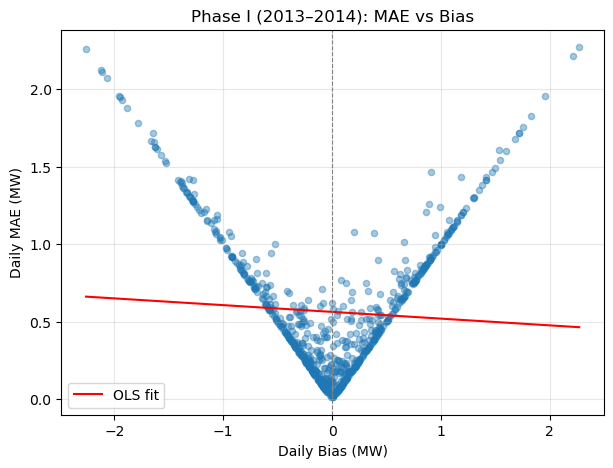


                           Simulation  Actuals  error
Datetime                                             
2013-01-02 08:00:00+01:00       0.036    0.060 -0.024
2013-01-02 09:00:00+01:00       0.280    0.509 -0.229
2013-01-02 10:00:00+01:00       0.665    0.827 -0.162
2013-01-02 11:00:00+01:00       0.492    0.935 -0.444
2013-01-02 12:00:00+01:00       0.404    0.992 -0.589
2013-01-02 13:00:00+01:00       0.647    1.330 -0.684
2013-01-02 14:00:00+01:00       0.529    0.778 -0.249
2013-01-02 15:00:00+01:00       0.301    0.287  0.015
2013-01-02 16:00:00+01:00       0.034    0.035 -0.000
2013-01-03 08:00:00+01:00       0.005    0.067 -0.062
2013-01-03 09:00:00+01:00       0.053    0.693 -0.640
2013-01-03 10:00:00+01:00       0.158    1.413 -1.255
2013-01-03 11:00:00+01:00       0.175    1.903 -1.729
2013-01-03 12:00:00+01:00       0.152    2.064 -1.913
2013-01-03 13:00:00+01:00       0.081    1.879 -1.798
2013-01-03 14:00:00+01:00       0.096    1.367 -1.271
2013-01-03 15:00:00+01:00  

In [25]:
# Appendix: Correlation between daily MAE and Bias in Phase I (2013–2014)

phase1 = tmp.loc["2013-01-01":"2014-12-31"].dropna()

print(phase1.head())
print(phase1.shape)

# Pearson correlation
print("Pearson correlations (Phase I 2013-2014):")
print(phase1[["MAE", "Bias", "AbsBias"]].corr(method="pearson"))

print()

# Spearman correlation
print("Spearman correlations (Phase I 2013-2014):")
print(phase1[["MAE", "Bias", "AbsBias"]].corr(method="spearman"))


plt.figure(figsize=(7, 5))
plt.scatter(phase1["Bias"], phase1["MAE"], alpha=0.4, s=20)


z = np.polyfit(phase1["Bias"].dropna(), phase1["MAE"].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(phase1["Bias"].min(), phase1["Bias"].max(), 300)
plt.plot(x_line, p(x_line), color="red", linewidth=1.5, label="OLS fit")

plt.axvline(0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Daily Bias (MW)")
plt.ylabel("Daily MAE (MW)")
plt.title("Phase I (2013–2014): MAE vs Bias")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print()
# 2013-01-02 to 2013-01-06 error pattern
print(df_solar.loc["2013-01-02":"2013-01-06", ["Simulation", "Actuals", "error"]])


In [26]:
# =========================
# EWMA + MBB Bootstrap
# =========================

# ── Phase I ──
phase1_mae  = baseline_df["MAE"].dropna().copy()
phase1_zbias = baseline_df["Bias_standardized"].dropna().copy()

# 
assert phase1_mae.index.equals(phase1_zbias.index), "MAE and ZBias indices do not match!"

phase1_season = baseline_df.loc[phase1_mae.index, "Season"].astype(str).copy()

print(f"Phase I sample: {len(phase1_mae)} days")
print(phase1_season.value_counts())

print()
# =========================
# EWMA function
# =========================
LAM = 0.2  

def compute_ewma(series_array, lam, init):
    """
    E_t = lam * X_t + (1-lam) * E_{t-1}
    series_array : np.ndarray
    init         :  E_0
    """
    series_array = np.asarray(series_array, dtype=float)
    T = len(series_array)
    ewma = np.empty(T,dtype=float)
    ewma[0] = lam * series_array[0] + (1 - lam) * init
    for t in range(1, T):
        ewma[t] = lam * series_array[t] + (1 - lam) * ewma[t - 1]
    return ewma

# Initial values consistent with thesis design 
init_mae  = phase1_mae.mean()   # MAE chart: Phase I mean
init_zbias = 0.0                 # Bias chart: centered at zero after standardization

#  orignial Phase I EWMA paths
ewma_mae_phase1   = compute_ewma(phase1_mae.values,   LAM, init_mae)
ewma_zbias_phase1 = compute_ewma(phase1_zbias.values, LAM, init_zbias)

print(f"EWMA MAE   — mean: {ewma_mae_phase1.mean():.1f}, max: {ewma_mae_phase1.max():.1f}")
print(f"EWMA ZBias — mean: {ewma_zbias_phase1.mean():.3f}, max: {ewma_zbias_phase1.max():.3f}")

Phase I sample: 730 days
Season
Spring    184
Summer    184
Autumn    182
Winter    180
Name: count, dtype: int64

EWMA MAE   — mean: 0.6, max: 1.4
EWMA ZBias — mean: -0.000, max: 1.321


In [27]:

# =========================================================
#  global Moving Block Bootstrap helper
# =========================================================
def mbb_resample_path(series, block_length, rng):
    """
    Create one moving block bootstrap sample of the same length as series.
    """
    series = np.asarray(series, dtype=float)
    T = len(series)

    if block_length > T:
        raise ValueError("block_length cannot exceed sample length.")

    start_indices = np.arange(T - block_length + 1)
    n_blocks_needed = int(np.ceil(T / block_length))

    starts = rng.choice(start_indices, size=n_blocks_needed, replace=True)
    boot = np.concatenate([series[s:s + block_length] for s in starts])[:T]
    return boot

# =========================================================
#  Global MBB + season-conditioned UCL for MAE chart
# =========================================================
def mbb_global_seasonal_ucl(
    series, seasons, lam, init,
    block_length=21, B=5000, quantile=0.995, seed=42
):
    """
    Global moving block bootstrap for MAE chart,
    with season-conditioned upper control limits.

    Parameters
    ----------
    series : np.ndarray
        Phase I raw MAE series in time order.
    seasons : np.ndarray of str
        Season label for each time position in Phase I.
    lam : float
        EWMA smoothing parameter.
    init : float
        Initial EWMA value E_0.
    block_length : int
        MBB block length.
    B : int
        Number of bootstrap replications.
    quantile : float
        Upper quantile level for UCL.
    seed : int
        Random seed.

    Returns
    -------
    seasonal_ucl : dict
        Season-specific UCL, e.g. {"Winter": ..., ...}
    all_paths : np.ndarray
        Bootstrap EWMA paths, shape (B, T)
    """
    rng = np.random.default_rng(seed)
    series = np.asarray(series, dtype=float)
    seasons = np.asarray(seasons)
    T = len(series)

    if len(seasons) != T:
        raise ValueError("series and seasons must have the same length.")

    all_paths = np.empty((B, T), dtype=float)

    for b in range(B):
        boot = mbb_resample_path(series, block_length=block_length, rng=rng)
        all_paths[b] = compute_ewma(boot, lam=lam, init=init)

    seasonal_ucl = {}
    for s in np.unique(seasons):
        mask = (seasons == s)
        season_values = all_paths[:, mask].ravel()
        seasonal_ucl[s] = np.quantile(season_values, quantile)

    return seasonal_ucl, all_paths

# =========================================================
# 4. Main specification for MAE chart
# =========================================================
BLOCK_LENGTH = 21   # main specification
B_REP = 5000
UPPER_Q = 0.995
SEED = 42

ucl_mae_B, paths_mae_B = mbb_global_seasonal_ucl(
    series=phase1_mae.values,
    seasons=phase1_season.values,
    lam=LAM,
    init=init_mae,
    block_length=BLOCK_LENGTH,
    B=B_REP,
    quantile=UPPER_Q,
    seed=SEED
)

# =========================================================
# Print season-specific UCLs
# =========================================================
season_order = ["Winter", "Spring", "Summer", "Autumn"]

print("\nMAE chart: season-conditioned UCLs")
print(f"{'Season':<10} {'UCL_MAE (MW)':>14}")
print("-" * 26)
for s in season_order:
    if s in ucl_mae_B:
        print(f"{s:<10} {ucl_mae_B[s]:>14.1f}")

# =========================================================
#  Phase I exceedance check
# =========================================================
ucl_aligned = phase1_season.map(ucl_mae_B)

if ucl_aligned.isna().any():
    missing_seasons = phase1_season[ucl_aligned.isna()].unique()
    raise ValueError(f"Missing UCL for seasons: {missing_seasons}")

mae_alarm_phase1 = ewma_mae_phase1 > ucl_aligned.to_numpy()

print("\nPhase I MAE alarm summary")
print(f"MAE alarms in Phase I: {mae_alarm_phase1.sum()} / {len(mae_alarm_phase1)}")


MAE chart: season-conditioned UCLs
Season       UCL_MAE (MW)
--------------------------
Winter                1.3
Spring                1.3
Summer                1.3
Autumn                1.3

Phase I MAE alarm summary
MAE alarms in Phase I: 4 / 730


In [28]:
# Phase I alarm table by season （global MBB + season-conditioned UCL specification）
alarm_df = pd.DataFrame({
    "EWMA_MAE": ewma_mae_phase1,
    "UCL": ucl_aligned,
    "Season": phase1_season.values,
    "Alarm": mae_alarm_phase1
}, index=phase1_mae.index)

print("Phase I MAE alarm by season:")
print(alarm_df.groupby("Season")["Alarm"].agg(
    total="count",
    alarms="sum",
    alarm_rate=lambda x: f"{x.mean()*100:.2f}%"
).loc[season_order])

Phase I MAE alarm by season:
        total  alarms alarm_rate
Season                          
Winter    180       0      0.00%
Spring    184       0      0.00%
Summer    184       4      2.17%
Autumn    182       0      0.00%


In [29]:
print("Current init_mae:", init_mae)
print("Phase I MAE mean:", phase1_mae.mean())

Current init_mae: 0.5645067208768224
Phase I MAE mean: 0.5645067208768224


In [30]:
# =========================================================
#  Phase I input for MAE chart
# =========================================================

phase1_mae = baseline_df["MAE"].dropna().copy()
phase1_season = baseline_df.loc[phase1_mae.index, "Season"].astype(str).copy()

season_order = ["Winter", "Spring", "Summer", "Autumn"]

print(f"Phase I MAE sample: {len(phase1_mae)} days")
print(phase1_season.value_counts().reindex(season_order))

# =========================================================
# 1. EWMA function
# =========================================================
LAM = 0.2

def compute_ewma(series_array, lam, init):
    """
    EWMA recursion:
        E_t = lam * X_t + (1-lam) * E_{t-1}
    where init is E_0.

    Parameters
    ----------
    series_array : np.ndarray
        Input series in time order.
    lam : float
        EWMA smoothing parameter.
    init : float
        Initial value E_0.

    Returns
    -------
    ewma : np.ndarray
        EWMA path of same length as input.
        ewma[0] corresponds to E_1 in the recursion.
    """
    series_array = np.asarray(series_array, dtype=float)
    T = len(series_array)
    ewma = np.empty(T, dtype=float)

    ewma[0] = lam * series_array[0] + (1 - lam) * init
    for t in range(1, T):
        ewma[t] = lam * series_array[t] + (1 - lam) * ewma[t - 1]
    return ewma

# =========================================================
# 2. Full-calendar EWMA path (the monitored object)
# =========================================================
# keep the same init for both full-calendar path and bootstrap paths to ensure comparability
init_mae = phase1_mae.mean()
ewma_mae_phase1 = compute_ewma(phase1_mae.values, lam=LAM, init=init_mae)

print(f"\nFull-calendar EWMA MAE — mean: {ewma_mae_phase1.mean():.1f}, "
      f"min: {ewma_mae_phase1.min():.1f}, max: {ewma_mae_phase1.max():.1f}")

# =========================================================
# 3.  Moving Block Bootstrap helper
# =========================================================
def mbb_resample_path(series, block_length, rng):
    """
    Create one moving block bootstrap sample of the same length as series.
    """
    series = np.asarray(series, dtype=float)
    T = len(series)

    if block_length > T:
        raise ValueError("block_length cannot exceed sample length.")

    start_indices = np.arange(T - block_length + 1)
    n_blocks_needed = int(np.ceil(T / block_length))

    starts = rng.choice(start_indices, size=n_blocks_needed, replace=True)
    boot = np.concatenate([series[s:s + block_length] for s in starts])[:T]
    return boot

# =========================================================
# 4. Scheme A:
#    season-specific independent bootstrap calibration
# =========================================================
def mbb_by_season_ucl(
    series, seasons, lam, init,
    block_length=21, B=5000, quantile=0.995, seed=42
):
    """
    Scheme A:
    Calibrate MAE UCL separately within each seasonal subseries.

    IMPORTANT:
    This function operates on season-specific subseries, not on the
    full calendar-time series. Therefore, it is best interpreted as an
    alternative / robustness design emphasizing seasonal adaptation.

    Parameters
    ----------
    series : np.ndarray
        Full Phase I raw MAE series in original time order.
    seasons : np.ndarray of str
        Season label for each time point.
    lam : float
        EWMA smoothing parameter.
    init : float
        Global initial EWMA value E_0 used in bootstrap EWMA construction.
    block_length : int
        MBB block length.
    B : int
        Number of bootstrap replications.
    quantile : float
        Upper quantile level for UCL.
    seed : int
        Random seed.

    Returns
    -------
    ucl : dict
        Season-specific UCL.
    season_paths : dict
        Bootstrap EWMA paths for each season.
    season_sizes : dict
        Sample size for each season.
    """
    rng = np.random.default_rng(seed)
    series = np.asarray(series, dtype=float)
    seasons = np.asarray(seasons)

    if len(series) != len(seasons):
        raise ValueError("series and seasons must have the same length.")

    ucl = {}
    season_paths = {}
    season_sizes = {}

    for s in np.unique(seasons):
        mask = (seasons == s)
        s_series = series[mask]
        T_s = len(s_series)
        season_sizes[s] = T_s

        if block_length > T_s:
            raise ValueError(
                f"block_length={block_length} exceeds sample length in {s} (T={T_s})"
            )

        all_paths = np.empty((B, T_s), dtype=float)

        for b in range(B):
            boot = mbb_resample_path(s_series, block_length=block_length, rng=rng)
            all_paths[b] = compute_ewma(boot, lam=lam, init=init)

        ucl[s] = np.quantile(all_paths.ravel(), quantile)
        season_paths[s] = all_paths

    return ucl, season_paths, season_sizes

# =========================================================
# 5. Main specification for Scheme A
# =========================================================
BLOCK_LENGTH = 21
B_REP = 5000
UPPER_Q = 0.995
SEED = 42

ucl_mae_A, paths_mae_A, season_sizes_A = mbb_by_season_ucl(
    series=phase1_mae.values,
    seasons=phase1_season.values,
    lam=LAM,
    init=init_mae,          
    block_length=BLOCK_LENGTH,
    B=B_REP,
    quantile=UPPER_Q,
    seed=SEED
)

# =========================================================
# 6. Print season-specific UCLs
# =========================================================
print("\nScheme A: season-specific independent UCLs")
print(f"{'Season':<10} {'SampleSize':>10} {'UCL_MAE (MW)':>14}")
print("-" * 38)
for s in season_order:
    if s in ucl_mae_A:
        print(f"{s:<10} {season_sizes_A[s]:>10} {ucl_mae_A[s]:>14.1f}")

# =========================================================
# 7. Align UCLs back to full-calendar dates
# =========================================================
ucl_aligned_A = phase1_season.map(ucl_mae_A)

if ucl_aligned_A.isna().any():
    missing_seasons = phase1_season[ucl_aligned_A.isna()].unique()
    raise ValueError(f"Missing UCL for seasons: {missing_seasons}")

mae_alarm_A = ewma_mae_phase1 > ucl_aligned_A.to_numpy()

# =========================================================
# 8. Phase I alarm summary by season
# =========================================================
alarm_df_A = pd.DataFrame({
    "EWMA_MAE": ewma_mae_phase1,
    "UCL": ucl_aligned_A.to_numpy(),
    "Season": phase1_season.values,
    "Alarm": mae_alarm_A
}, index=phase1_mae.index)

alarm_summary_A = alarm_df_A.groupby("Season")["Alarm"].agg(
    total="count",
    alarms="sum",
    alarm_rate=lambda x: x.mean()
).reindex(season_order)

alarm_summary_A["alarm_rate_pct"] = (alarm_summary_A["alarm_rate"] * 100).round(2)

print("\nPhase I MAE alarm by season (Scheme A)")
print(alarm_summary_A)

# =========================================================
# 9. Optional comparison with Scheme B
# =========================================================


if "ucl_mae_B" in globals():
    print("\nScheme A vs Scheme B UCL comparison")
    print(f"{'Season':<10} {'UCL_A':>12} {'UCL_B':>12} {'Diff(A-B)':>12}")
    print("-" * 46)
    for s in season_order:
        if s in ucl_mae_A and s in ucl_mae_B:
            diff = ucl_mae_A[s] - ucl_mae_B[s]
            print(f"{s:<10} {ucl_mae_A[s]:>12.1f} {ucl_mae_B[s]:>12.1f} {diff:>12.1f}")

Phase I MAE sample: 730 days
Season
Winter    180
Spring    184
Summer    184
Autumn    182
Name: count, dtype: int64

Full-calendar EWMA MAE — mean: 0.6, min: 0.1, max: 1.4



Scheme A: season-specific independent UCLs
Season     SampleSize   UCL_MAE (MW)
--------------------------------------
Winter            180            0.5
Spring            184            1.3
Summer            184            1.4
Autumn            182            0.9

Phase I MAE alarm by season (Scheme A)
        total  alarms  alarm_rate  alarm_rate_pct
Season                                           
Winter    180       0       0.000           0.000
Spring    184       1       0.005           0.540
Summer    184       1       0.005           0.540
Autumn    182       7       0.038           3.850

Scheme A vs Scheme B UCL comparison
Season            UCL_A        UCL_B    Diff(A-B)
----------------------------------------------
Winter              0.5          1.3         -0.8
Spring              1.3          1.3         -0.1
Summer              1.4          1.3          0.1
Autumn              0.9          1.3         -0.4


In [31]:
# check the alarmed points  for Scheme A
# 
all_alarms = alarm_df_A[alarm_df_A["Alarm"] == True]
print(all_alarms[["EWMA_MAE", "UCL", "Season"]])
print()

# examine the error pattern around the alarmed points (5 days before and after)
for date in all_alarms.index:
    start = date - pd.Timedelta(days=5)
    end = date + pd.Timedelta(days=5)
    print(f"\n{'='*50}")
    print(f"Alarm date: {date.date()}  Season: {all_alarms.loc[date, 'Season']}")
    print(f"EWMA: {all_alarms.loc[date, 'EWMA_MAE']:.1f}  UCL: {all_alarms.loc[date, 'UCL']:.1f}")
    print(baseline_df.loc[start:end, ["MAE", "Season"]])


            EWMA_MAE   UCL  Season
2014-05-20     1.301 1.255  Spring
2014-07-10     1.435 1.435  Summer
2014-09-03     0.923 0.889  Autumn
2014-09-04     0.955 0.889  Autumn
2014-09-05     1.029 0.889  Autumn
2014-09-06     0.986 0.889  Autumn
2014-09-07     1.026 0.889  Autumn
2014-09-08     0.923 0.889  Autumn
2014-09-12     0.895 0.889  Autumn


Alarm date: 2014-05-20  Season: Spring
EWMA: 1.3  UCL: 1.3
             MAE  Season
2014-05-15 1.029  Spring
2014-05-16 0.772  Spring
2014-05-17 0.641  Spring
2014-05-18 1.066  Spring
2014-05-19 1.606  Spring
2014-05-20 2.270  Spring
2014-05-21 1.047  Spring
2014-05-22 0.540  Spring
2014-05-23 0.577  Spring
2014-05-24 0.869  Spring
2014-05-25 1.413  Spring

Alarm date: 2014-07-10  Season: Summer
EWMA: 1.4  UCL: 1.4
             MAE  Season
2014-07-05 1.423  Summer
2014-07-06 0.599  Summer
2014-07-07 1.281  Summer
2014-07-08 2.113  Summer
2014-07-09 1.664  Summer
2014-07-10 2.070  Summer
2014-07-11 0.757  Summer
2014-07-12 1.947  Summer
2014

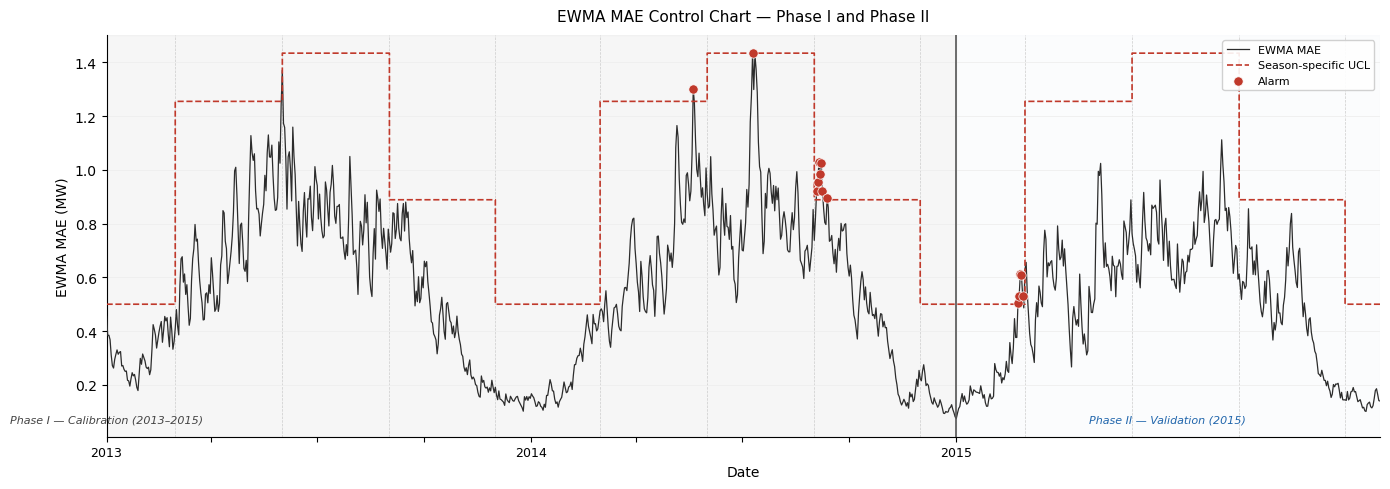

In [32]:
# =========================================================
#  Prepare Phase II data 2013-01-01 to 2015-12-31
# ========================================================= 

full_mae = daily_mae.loc["2013-01-01":"2015-12-31"].dropna() # ensure full calendar coverage
full_mae.index = pd.to_datetime(full_mae.index).tz_localize(None)

# season labels for the full calendar period (for UCL alignment and plotting)
full_season = full_mae.index.month.map(
    lambda m: "Winter" if m in [12,1,2]
    else "Spring" if m in [3,4,5]
    else "Summer" if m in [6,7,8]
    else "Autumn"
)
full_season = pd.Series(full_season.values, index=full_mae.index)

# =========================================================
# 1. Compute full EWMA path (init from Phase I mean)
# =========================================================
ewma_full = compute_ewma(full_mae.values, lam=LAM, init=init_mae)
ewma_full = pd.Series(ewma_full, index=full_mae.index)

# =========================================================
# 2. Align season-specific UCL (from Scheme A)
# =========================================================
ucl_full = full_season.map(ucl_mae_A)

# =========================================================
# 3. Alarm flags
# =========================================================
alarm_full = ewma_full > ucl_full

# =========================================================
# 4. Phase I / II boundary
# =========================================================
phase1_end = pd.Timestamp("2014-12-31")
phase2_start = pd.Timestamp("2015-01-01")

# =========================================================
# 5. Season boundary dates (for vertical lines)
# =========================================================
def get_season_boundaries(index):
    """Return dates where season changes."""
    months = pd.Series(index.month, index=index)
    season = months.map(
        lambda m: "Winter" if m in [12,1,2]
        else "Spring" if m in [3,4,5]
        else "Summer" if m in [6,7,8]
        else "Autumn"
    )
    boundaries = index[season != season.shift(1)].tolist()
    return boundaries[1:]  # skip first

season_boundaries = get_season_boundaries(full_mae.index)

# =========================================================
# 6. Plot
# =========================================================
fig, ax = plt.subplots(figsize=(14, 5))

# ── Phase I/II background shading ──
ax.axvspan(full_mae.index[0], phase2_start,
           alpha=0.04, color="#2c2c2c", zorder=0)
ax.axvspan(phase2_start, full_mae.index[-1],
           alpha=0.015, color="#2166ac", zorder=0)

# ── Season boundaries (light gray vertical lines, no labels) ──
for bd in season_boundaries:
    ax.axvline(bd, color="#cccccc", linewidth=0.5,
               linestyle="--", zorder=1)

# ── Phase I/II boundary ──
ax.axvline(phase2_start, color="#555555", linewidth=1.2,
           linestyle="-", zorder=4)

# ── EWMA line ──
ax.plot(ewma_full.index, ewma_full.values,
        color="#2c2c2c", linewidth=0.9,
        label="EWMA MAE", zorder=3)

# ── UCL as step line ──
ax.step(ucl_full.index, ucl_full.values,
        where="post",
        color="#c0392b", linewidth=1.2,
        linestyle="--", label="Season-specific UCL", zorder=3)

# ── Alarm points ──
alarm_dates = ewma_full.index[alarm_full]
alarm_vals  = ewma_full[alarm_full]
ax.scatter(alarm_dates, alarm_vals,
           color="#c0392b", s=45, zorder=5,
           label="Alarm", marker="o", edgecolors="white", linewidths=0.5)

# ── Phase I / II text at bottom ──
ymin, ymax = ax.get_ylim()
y_text = ymin + (ymax - ymin) * 0.03

ax.text(pd.Timestamp("2013-01-01"), y_text,
        "Phase I — Calibration (2013–2015)",
        fontsize=8, color="#444444",
        ha="center", va="bottom", style="italic")
ax.text(pd.Timestamp("2015-07-01"), y_text,
        "Phase II — Validation (2015)",
        fontsize=8, color="#2166ac",
        ha="center", va="bottom", style="italic")

# ── x-axis: quarterly ticks, year labels only ──
quarterly = pd.date_range("2013-01-01", "2015-01-01", freq="QS")
ax.set_xticks(quarterly)
ax.set_xticklabels([
    d.strftime("%Y") if d.month == 1 else ""
    for d in quarterly
], fontsize=9)

# ── Labels and formatting ──
ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel("EWMA MAE (MW)", fontsize=10)
ax.set_title("EWMA MAE Control Chart — Phase I and Phase II",
             fontsize=11, fontweight="normal", pad=10)

ax.legend(loc="upper right", fontsize=8, framealpha=0.9,
          edgecolor="#cccccc")
ax.grid(axis="y", color="#eeeeee", linewidth=0.6, zorder=0)
ax.set_xlim(full_mae.index[0], full_mae.index[-1])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("ewma_mae_chart.pdf", dpi=300, bbox_inches="tight")
plt.savefig("ewma_mae_chart.png", dpi=300, bbox_inches="tight")
plt.show()


In [33]:
# Phase II alarm details of MAE chart (Scheme A)
phase2_alarms = pd.DataFrame({
    "EWMA_MAE": ewma_full,
    "UCL":      ucl_full,
    "Season":   full_season,
    "Alarm":    alarm_full
}, index=full_mae.index)

phase2_only = phase2_alarms.loc["2015-01-01":]
print(phase2_only[phase2_only["Alarm"] == True][["EWMA_MAE", "UCL", "Season"]])
print()

print(daily_mae.loc["2015-01-17":"2015-04-30"])
print()
print(daily_mae.loc["2015-05-28":"2015-08-16"])

            EWMA_MAE   UCL  Season
2015-02-23     0.506 0.500  Winter
2015-02-24     0.531 0.500  Winter
2015-02-25     0.612 0.500  Winter
2015-02-26     0.607 0.500  Winter
2015-02-27     0.532 0.500  Winter

2015-01-17   0.164
2015-01-18   0.154
2015-01-19   0.168
2015-01-20   0.164
2015-01-21   0.158
              ... 
2015-04-26   0.363
2015-04-27   0.245
2015-04-28   0.467
2015-04-29   0.626
2015-04-30   0.597
Name: error, Length: 104, dtype: float64

2015-05-28   0.356
2015-05-29   0.896
2015-05-30   0.980
2015-05-31   1.332
2015-06-01   0.257
              ... 
2015-08-12   0.831
2015-08-13   0.724
2015-08-14   0.862
2015-08-15   0.843
2015-08-16   1.697
Name: error, Length: 81, dtype: float64


In [34]:
# =========================================================
#  Phase I input for ZBias chart
# =========================================================
phase1_zbias = baseline_df["Bias_standardized"].dropna().copy()
phase1_zbias_season = baseline_df.loc[phase1_zbias.index, "Season"].astype(str).copy()

print(f"Phase I ZBias sample: {len(phase1_zbias)} days")
print(f"Mean: {phase1_zbias.mean():.4f}, Std: {phase1_zbias.std():.4f}")
print(f"Min:  {phase1_zbias.min():.4f}, Max: {phase1_zbias.max():.4f}")

# =========================================================
# 1. Full-calendar EWMA path for ZBias
# =========================================================
init_zbias = 0.0  # zero-centered by construction

ewma_zbias_phase1 = compute_ewma(phase1_zbias.values, lam=LAM, init=init_zbias)

print(f"\nEWMA ZBias — mean: {ewma_zbias_phase1.mean():.4f}, "
      f"min: {ewma_zbias_phase1.min():.4f}, "
      f"max: {ewma_zbias_phase1.max():.4f}")

# =========================================================
# 2. Global MBB + common two-sided limits
# =========================================================
def mbb_global_common_limits(
    series, lam, init,
    block_length=21, B=5000,
    upper_q=0.995, lower_q=0.005,
    seed=42
):
    """
    Global MBB bootstrap for ZBias chart.
    Returns common two-sided control limits (not season-specific).

    Parameters
    ----------
    series      : np.ndarray, Phase I ZBias series in time order
    lam         : float, EWMA smoothing parameter
    init        : float, initial EWMA value E_0
    block_length: int, MBB block length
    B           : int, bootstrap replications
    upper_q     : float, upper quantile level (0.995)
    lower_q     : float, lower quantile level (0.005)
    seed        : int, random seed

    Returns
    -------
    ucl         : float, upper control limit
    lcl         : float, lower control limit
    all_paths   : np.ndarray, shape (B, T), bootstrap EWMA paths
    """
    rng = np.random.default_rng(seed)
    series = np.asarray(series, dtype=float)
    T = len(series)

    all_paths = np.empty((B, T), dtype=float)

    for b in range(B):
        boot = mbb_resample_path(series, block_length=block_length, rng=rng)
        all_paths[b] = compute_ewma(boot, lam=lam, init=init)

    ucl = np.quantile(all_paths.ravel(), upper_q)
    lcl = np.quantile(all_paths.ravel(), lower_q)

    return ucl, lcl, all_paths


# =========================================================
# 3. Main specification
# =========================================================
ucl_zbias, lcl_zbias, paths_zbias = mbb_global_common_limits(
    series=phase1_zbias.values,
    lam=LAM,
    init=init_zbias,
    block_length=BLOCK_LENGTH,
    B=B_REP,
    upper_q=0.995,
    lower_q=0.005,
    seed=SEED
)

print(f"\nZBias chart: common two-sided limits")
print(f"UCL: {ucl_zbias:.4f}")
print(f"LCL: {lcl_zbias:.4f}")
print(f"Symmetric: {abs(abs(ucl_zbias) - abs(lcl_zbias)) < 0.01}")

# =========================================================
# 4. Phase I alarm check
# =========================================================
alarm_upper_phase1 = ewma_zbias_phase1 > ucl_zbias
alarm_lower_phase1 = ewma_zbias_phase1 < lcl_zbias
alarm_zbias_phase1 = alarm_upper_phase1 | alarm_lower_phase1

print(f"\nPhase I ZBias alarm summary")
print(f"Upper alarms: {alarm_upper_phase1.sum()} / {len(ewma_zbias_phase1)}")
print(f"Lower alarms: {alarm_lower_phase1.sum()} / {len(ewma_zbias_phase1)}")
print(f"Total alarms: {alarm_zbias_phase1.sum()} / {len(ewma_zbias_phase1)}")
print(f"Total alarm rate: {alarm_zbias_phase1.mean()*100:.2f}%")

# =========================================================
# 5. Phase I alarm by season
# =========================================================
alarm_df_zbias = pd.DataFrame({
    "EWMA_ZBias": ewma_zbias_phase1,
    "UCL": ucl_zbias,
    "LCL": lcl_zbias,
    "Season": phase1_zbias_season.values,
    "Alarm_upper": alarm_upper_phase1,
    "Alarm_lower": alarm_lower_phase1,
    "Alarm": alarm_zbias_phase1
}, index=phase1_zbias.index)

summary_zbias = alarm_df_zbias.groupby("Season").agg(
    total=("Alarm", "count"),
    upper_alarms=("Alarm_upper", "sum"),
    lower_alarms=("Alarm_lower", "sum"),
    total_alarms=("Alarm", "sum"),
    alarm_rate=("Alarm", lambda x: f"{x.mean()*100:.2f}%")
).reindex(season_order)

print("\nPhase I ZBias alarm by season:")
print(summary_zbias)

Phase I ZBias sample: 730 days
Mean: -0.0000, Std: 0.9979
Min:  -3.1373, Max: 3.3314

EWMA ZBias — mean: -0.0004, min: -1.4243, max: 1.3205

ZBias chart: common two-sided limits
UCL: 1.0369
LCL: -1.3184
Symmetric: False

Phase I ZBias alarm summary
Upper alarms: 3 / 730
Lower alarms: 5 / 730
Total alarms: 8 / 730
Total alarm rate: 1.10%

Phase I ZBias alarm by season:
        total  upper_alarms  lower_alarms  total_alarms alarm_rate
Season                                                            
Winter    180             1             0             1      0.56%
Spring    184             2             0             2      1.09%
Summer    184             0             3             3      1.63%
Autumn    182             0             2             2      1.10%


In [35]:
# Phase I ZBias alarms details
phase1_zbias_alarms = alarm_df_zbias[alarm_df_zbias["Alarm"] == True]
print(phase1_zbias_alarms[["EWMA_ZBias", "UCL", "LCL", "Alarm_upper", "Alarm_lower", "Season"]])



for date in phase1_zbias_alarms.index:
    start = date - pd.Timedelta(days=5)
    end = date + pd.Timedelta(days=5)
    print(f"\nAlarm: {date.date()}  Season: {phase1_zbias_alarms.loc[date, 'Season']}")
    print(f"EWMA_ZBias: {phase1_zbias_alarms.loc[date, 'EWMA_ZBias']:.4f}")
    print(baseline_df.loc[start:end, ["Bias", "Bias_standardized", "Season"]])

            EWMA_ZBias   UCL    LCL  Alarm_upper  Alarm_lower  Season
2013-06-01      -1.346 1.037 -1.318        False         True  Summer
2014-02-25       1.104 1.037 -1.318         True        False  Winter
2014-05-20       1.321 1.037 -1.318         True        False  Spring
2014-05-21       1.314 1.037 -1.318         True        False  Spring
2014-07-12      -1.397 1.037 -1.318        False         True  Summer
2014-07-13      -1.357 1.037 -1.318        False         True  Summer
2014-09-05      -1.324 1.037 -1.318        False         True  Autumn
2014-09-07      -1.424 1.037 -1.318        False         True  Autumn

Alarm: 2013-06-01  Season: Summer
EWMA_ZBias: -1.3459
             Bias  Bias_standardized  Season
2013-05-27 -0.833             -1.003  Spring
2013-05-28  1.057              1.298  Spring
2013-05-29 -1.931             -2.341  Spring
2013-05-30 -0.703             -0.845  Spring
2013-05-31 -2.121             -2.572  Spring
2013-06-01 -1.880             -2.126  Summer


Full ZBias series: 1095 days
Range: -3.605 to 3.483

Phase II ZBias alarms: 8
            EWMA_ZBias   UCL    LCL  Alarm_upper  Alarm_lower  Season
2013-06-01      -1.346 1.037 -1.318        False         True  Summer
2014-02-25       1.104 1.037 -1.318         True        False  Winter
2014-05-20       1.321 1.037 -1.318         True        False  Spring
2014-05-21       1.314 1.037 -1.318         True        False  Spring
2014-07-12      -1.397 1.037 -1.318        False         True  Summer
2014-07-13      -1.357 1.037 -1.318        False         True  Summer
2014-09-05      -1.324 1.037 -1.318        False         True  Autumn
2014-09-07      -1.424 1.037 -1.318        False         True  Autumn


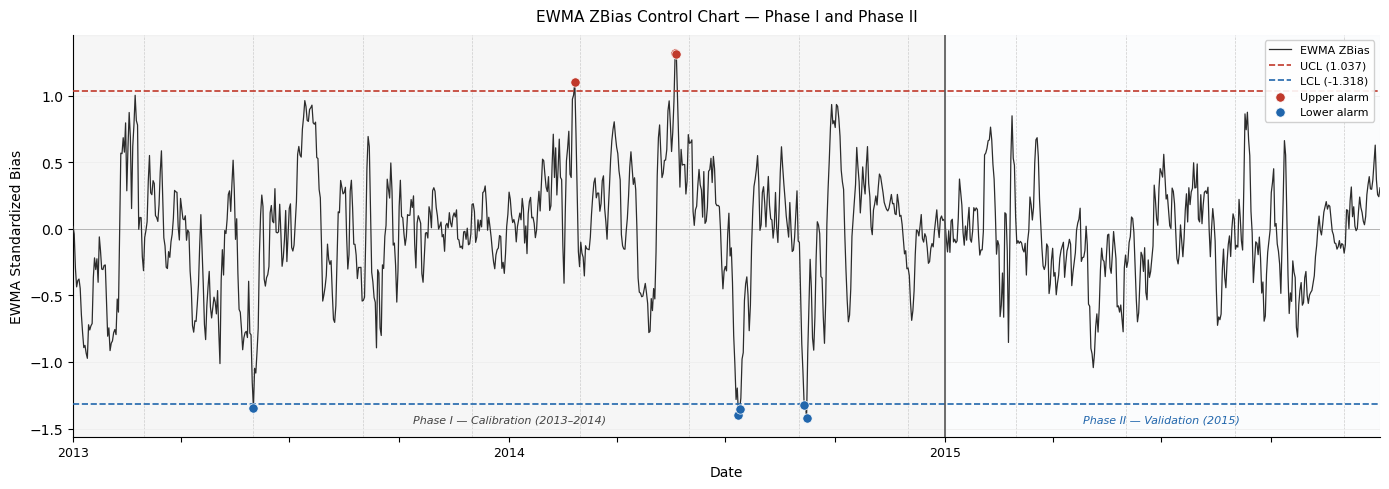

In [ ]:
# =========================================================
# 0. Prepare full ZBias series (Phase I + Phase II)
# =========================================================

# Phase I seasonal parameters for standardization

bias_season_mean = baseline_df.groupby("Season")["Bias"].mean()
bias_season_std  = baseline_df.groupby("Season")["Bias"].std()

# Build full 2013-2015 daily bias series
full_bias = daily_bias.loc["2013-01-01":"2015-12-31"].dropna()
full_bias.index = pd.to_datetime(full_bias.index).tz_localize(None)

# Assign season labels
full_bias_season = pd.Series(
    full_bias.index.month.map(
        lambda m: "Winter" if m in [12,1,2]
        else "Spring" if m in [3,4,5]
        else "Summer" if m in [6,7,8]
        else "Autumn"
    ).values,
    index=full_bias.index
)

# 2015-01-01 to 2015-12-31 ZBias series, standardized by Phase I seasonal parameters
full_zbias = (
    full_bias - full_bias_season.map(bias_season_mean)
) / full_bias_season.map(bias_season_std)

print(f"Full ZBias series: {len(full_zbias)} days")
print(f"Range: {full_zbias.min():.3f} to {full_zbias.max():.3f}")

# =========================================================
# 1. Full-calendar EWMA path
# =========================================================
ewma_zbias_full = compute_ewma(full_zbias.values, lam=LAM, init=init_zbias)
ewma_zbias_full = pd.Series(ewma_zbias_full, index=full_zbias.index)

# =========================================================
# 2. Alarm flags
# =========================================================
alarm_upper_full = ewma_zbias_full > ucl_zbias
alarm_lower_full = ewma_zbias_full < lcl_zbias
alarm_zbias_full = alarm_upper_full | alarm_lower_full

# =========================================================
# 3. Phase II alarm summary
# =========================================================
phase2_zbias = pd.DataFrame({
    "EWMA_ZBias": ewma_zbias_full,
    "UCL": ucl_zbias,
    "LCL": lcl_zbias,
    "Season": full_bias_season,
    "Alarm_upper": alarm_upper_full,
    "Alarm_lower": alarm_lower_full,
    "Alarm": alarm_zbias_full
}, index=full_zbias.index)

phase2_only_zbias = phase2_zbias.loc["2013-01-01":]
phase2_alarms_zbias = phase2_only_zbias[phase2_only_zbias["Alarm"]]

print(f"\nPhase II ZBias alarms: {len(phase2_alarms_zbias)}")
if len(phase2_alarms_zbias) > 0:
    print(phase2_alarms_zbias[["EWMA_ZBias", "UCL", "LCL",
                                "Alarm_upper", "Alarm_lower", "Season"]])

# =========================================================
# 4. Plot
# =========================================================
fig, ax = plt.subplots(figsize=(14, 5))

# ── Phase I/II background shading ──
ax.axvspan(full_zbias.index[0], phase2_start,
           alpha=0.04, color="#2c2c2c", zorder=0)
ax.axvspan(phase2_start, full_zbias.index[-1],
           alpha=0.015, color="#2166ac", zorder=0)

# ── Season boundaries ──
season_boundaries_z = get_season_boundaries(full_zbias.index)
for bd in season_boundaries_z:
    ax.axvline(bd, color="#cccccc", linewidth=0.5,
               linestyle="--", zorder=1)

# ── Phase I/II boundary ──
ax.axvline(phase2_start, color="#555555", linewidth=1.2,
           linestyle="-", zorder=4)

# ── Zero reference line ──
ax.axhline(0, color="#aaaaaa", linewidth=0.6,
           linestyle="-", zorder=2)

# ── EWMA line ──
ax.plot(ewma_zbias_full.index, ewma_zbias_full.values,
        color="#2c2c2c", linewidth=0.9,
        label="EWMA ZBias", zorder=3)

# ── UCL and LCL as horizontal lines ──
ax.axhline(ucl_zbias, color="#c0392b", linewidth=1.2,
           linestyle="--", label=f"UCL ({ucl_zbias:.3f})", zorder=3)
ax.axhline(lcl_zbias, color="#2166ac", linewidth=1.2,
           linestyle="--", label=f"LCL ({lcl_zbias:.3f})", zorder=3)

# ── Upper alarms ──
upper_dates = ewma_zbias_full.index[alarm_upper_full]
upper_vals  = ewma_zbias_full[alarm_upper_full]
ax.scatter(upper_dates, upper_vals,
           color="#c0392b", s=45, zorder=5,
           marker="o", edgecolors="white", linewidths=0.5,
           label="Upper alarm")

# ── Lower alarms ──
lower_dates = ewma_zbias_full.index[alarm_lower_full]
lower_vals  = ewma_zbias_full[alarm_lower_full]
ax.scatter(lower_dates, lower_vals,
           color="#2166ac", s=45, zorder=5,
           marker="o", edgecolors="white", linewidths=0.5,
           label="Lower alarm")

# ── Phase I/II text at bottom ──
ymin, ymax = ax.get_ylim()
y_text = ymin + (ymax - ymin) * 0.03

ax.text(pd.Timestamp("2014-01-01"), y_text,
        "Phase I — Calibration (2013–2014)",
        fontsize=8, color="#444444",
        ha="center", va="bottom", style="italic")
ax.text(pd.Timestamp("2015-07-01"), y_text,
        "Phase II — Validation (2015)",
        fontsize=8, color="#2166ac",
        ha="center", va="bottom", style="italic")

# ── x-axis ──
quarterly = pd.date_range("2013-01-01", "2016-01-01", freq="QS")
ax.set_xticks(quarterly)
ax.set_xticklabels([
    d.strftime("%Y") if d.month == 1 else ""
    for d in quarterly
], fontsize=9)

# ── Labels and formatting ──
ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel("EWMA Standardized Bias", fontsize=10)
ax.set_title("EWMA ZBias Control Chart — Phase I and Phase II",
             fontsize=11, fontweight="normal", pad=10)

ax.legend(loc="upper right", fontsize=8,
          framealpha=0.9, edgecolor="#cccccc")
ax.grid(axis="y", color="#eeeeee", linewidth=0.6, zorder=0)
ax.set_xlim(full_zbias.index[0], full_zbias.index[-1])
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("ewma_zbias_chart.pdf", dpi=300, bbox_inches="tight")
plt.savefig("ewma_zbias_chart.png", dpi=300, bbox_inches="tight")
plt.show()


In [37]:
print("Total filas phase2_only_zbias:", len(phase2_only_zbias))
print("Alarmas:", phase2_only_zbias["Alarm"].sum())
print("Columnas:", phase2_only_zbias.columns.tolist())
print(phase2_only_zbias.head())

Total filas phase2_only_zbias: 1095
Alarmas: 8
Columnas: ['EWMA_ZBias', 'UCL', 'LCL', 'Season', 'Alarm_upper', 'Alarm_lower', 'Alarm']
            EWMA_ZBias   UCL    LCL  Season  Alarm_upper  Alarm_lower  Alarm
2013-01-01       0.018 1.037 -1.318  Winter        False        False  False
2013-01-02      -0.039 1.037 -1.318  Winter        False        False  False
2013-01-03      -0.295 1.037 -1.318  Winter        False        False  False
2013-01-04      -0.436 1.037 -1.318  Winter        False        False  False
2013-01-05      -0.388 1.037 -1.318  Winter        False        False  False


In [38]:
# Phase II ZBias alarms details
for date in phase2_only_zbias[phase2_only_zbias["Alarm"] == True].index:
    start = date - pd.Timedelta(days=5)
    end = date + pd.Timedelta(days=5)
    print(f"\n{'='*50}")
    print(f"Alarm: {date.date()}  Season: {phase2_only_zbias.loc[date, 'Season']}")
    print(f"EWMA_ZBias: {phase2_only_zbias.loc[date, 'EWMA_ZBias']:.4f}  LCL: {phase2_only_zbias.loc[date, 'LCL']:.4f}")
    print(daily_bias.loc[start:end])


Alarm: 2013-06-01  Season: Summer
EWMA_ZBias: -1.3459  LCL: -1.3184
2013-05-27   -0.833
2013-05-28    1.057
2013-05-29   -1.931
2013-05-30   -0.703
2013-05-31   -2.121
2013-06-01   -1.880
2013-06-02    0.135
2013-06-03   -1.083
2013-06-04   -0.256
2013-06-05   -0.032
2013-06-06    1.826
Name: error, dtype: float64

Alarm: 2014-02-25  Season: Winter
EWMA_ZBias: 1.1037  LCL: -1.3184
2014-02-20    0.320
2014-02-21   -0.269
2014-02-22    0.055
2014-02-23    0.898
2014-02-24    0.287
2014-02-25    0.390
2014-02-26   -0.258
2014-02-27   -0.428
2014-02-28   -0.573
2014-03-01   -0.610
2014-03-02    0.513
Name: error, dtype: float64

Alarm: 2014-05-20  Season: Spring
EWMA_ZBias: 1.3205  LCL: -1.3184
2014-05-15    1.024
2014-05-16    0.082
2014-05-17   -0.223
2014-05-18    1.062
2014-05-19    1.535
2014-05-20    2.270
2014-05-21    1.046
2014-05-22   -0.282
2014-05-23   -0.574
2014-05-24   -0.855
2014-05-25    1.413
Name: error, dtype: float64

Alarm: 2014-05-21  Season: Spring
EWMA_ZBias: 1.31

In [41]:
# =========================================================
# 0. Prepare stress period data (2013-2014)
# =========================================================
stress_mae = daily_mae.loc["2013-01-01":"2014-12-31"].dropna().copy()
stress_mae.index = pd.to_datetime(stress_mae.index)

stress_bias = daily_bias.loc["2013-01-01":"2014-12-31"].dropna().copy()
stress_bias.index = pd.to_datetime(stress_bias.index)

# align indices
common_idx = stress_mae.index.intersection(stress_bias.index)
stress_mae = stress_mae.loc[common_idx].copy()
stress_bias = stress_bias.loc[common_idx].copy()

# season labels
stress_season = pd.Series(
    stress_mae.index.month.map(
        lambda m: "Winter" if m in [12, 1, 2]
        else "Spring" if m in [3, 4, 5]
        else "Summer" if m in [6, 7, 8]
        else "Autumn"
    ),
    index=stress_mae.index
)

# sanity checks for Phase I standardization parameters
if bias_season_std.isna().any() or (bias_season_std <= 0).any():
    raise ValueError("Invalid seasonal std from Phase I.")

# standardize Bias using Phase I seasonal parameters
stress_zbias = (
    stress_bias - stress_season.map(bias_season_mean)
) / stress_season.map(bias_season_std)

if not np.isfinite(stress_zbias).all():
    raise ValueError("Non-finite values found in stress_zbias after standardization.")

print(f"Stress period MAE:   {len(stress_mae)} days")
print(f"Stress period ZBias: {len(stress_zbias)} days")
print(f"\nStress MAE range:   {stress_mae.min():.1f} to {stress_mae.max():.1f} MW")
print(f"Stress ZBias range: {stress_zbias.min():.3f} to {stress_zbias.max():.3f}")

Stress period MAE:   730 days
Stress period ZBias: 730 days

Stress MAE range:   0.0 to 2.3 MW
Stress ZBias range: -3.137 to 3.331


In [43]:
# =========================================================
# 0. Index alignment check
# =========================================================
assert stress_mae.index.equals(stress_zbias.index), \
    "stress_mae and stress_zbias indices do not match"
assert stress_mae.index.equals(stress_season.index), \
    "stress_mae and stress_season indices do not match"

# =========================================================
# 1. EWMA paths for stress period
# =========================================================
ewma_stress_mae   = compute_ewma(stress_mae.values,   LAM, init_mae)
ewma_stress_zbias = compute_ewma(stress_zbias.values, LAM, 0.0)

ewma_stress_mae   = pd.Series(ewma_stress_mae,   index=stress_mae.index)
ewma_stress_zbias = pd.Series(ewma_stress_zbias, index=stress_zbias.index)

# =========================================================
# 2. Align UCLs and check NaN
# =========================================================
ucl_stress_mae = stress_season.map(ucl_mae_A)

if ucl_stress_mae.isna().any():
    missing = stress_season[ucl_stress_mae.isna()].unique()
    raise ValueError(f"Missing MAE UCL for seasons: {missing}")

# MAE alarms
alarm_stress_mae = ewma_stress_mae > ucl_stress_mae

# ZBias alarms
alarm_stress_upper = ewma_stress_zbias > ucl_zbias
alarm_stress_lower = ewma_stress_zbias < lcl_zbias
alarm_stress_zbias = alarm_stress_upper | alarm_stress_lower

# =========================================================
# 3. Build stress DataFrame
# =========================================================
alarm_df_stress = pd.DataFrame({
    "Year":        stress_mae.index.year,
    "Season":      stress_season.values,
    "EWMA_MAE":    ewma_stress_mae.values,
    "UCL_MAE":     ucl_stress_mae.values,
    "Alarm_MAE":   alarm_stress_mae.values,
    "EWMA_ZBias":  ewma_stress_zbias.values,
    "Alarm_Upper": alarm_stress_upper.values,
    "Alarm_Lower": alarm_stress_lower.values,
    "Alarm_ZBias": alarm_stress_zbias.values,
}, index=stress_mae.index)

# =========================================================
# 4. Yearly summary
# =========================================================
yearly = alarm_df_stress.groupby("Year").agg(
    total        = ("Alarm_MAE",   "count"),
    MAE_alarms   = ("Alarm_MAE",   "sum"),
    MAE_rate     = ("Alarm_MAE",   "mean"),
    ZBias_alarms = ("Alarm_ZBias", "sum"),
    ZBias_rate   = ("Alarm_ZBias", "mean"),
    Upper_alarms = ("Alarm_Upper", "sum"),
    Lower_alarms = ("Alarm_Lower", "sum"),
).reindex([2013, 2014])

yearly["MAE_rate_pct"]   = (yearly["MAE_rate"]   * 100).round(1)
yearly["ZBias_rate_pct"] = (yearly["ZBias_rate"] * 100).round(1)

print("=" * 60)
print("Stress period alarm summary by year")
print("=" * 60)
print(yearly[["total", "MAE_alarms", "MAE_rate_pct",
              "ZBias_alarms", "ZBias_rate_pct",
              "Upper_alarms", "Lower_alarms"]])

# =========================================================
# 5. Stress vs Phase I comparison
# =========================================================
phase1_mae_rate   = mae_alarm_A.mean()
phase1_zbias_rate = alarm_zbias_phase1.mean()

stress_mae_rate   = alarm_stress_mae.mean()
stress_zbias_rate = alarm_stress_zbias.mean()

print("\n" + "=" * 60)
print("Overall alarm rates: stress period vs Phase I")
print("=" * 60)
print(f"MAE   — stress: {stress_mae_rate*100:.1f}%  "
      f"| Phase I: {phase1_mae_rate*100:.1f}%")
print(f"ZBias — stress: {stress_zbias_rate*100:.1f}%  "
      f"| Phase I: {phase1_zbias_rate*100:.1f}%")

Stress period alarm summary by year
      total  MAE_alarms  MAE_rate_pct  ZBias_alarms  ZBias_rate_pct  \
Year                                                                  
2013    365           0         0.000             1           0.300   
2014    365           9         2.500             7           1.900   

      Upper_alarms  Lower_alarms  
Year                              
2013             0             1  
2014             3             4  

Overall alarm rates: stress period vs Phase I
MAE   — stress: 1.2%  | Phase I: 1.2%
ZBias — stress: 1.1%  | Phase I: 1.1%


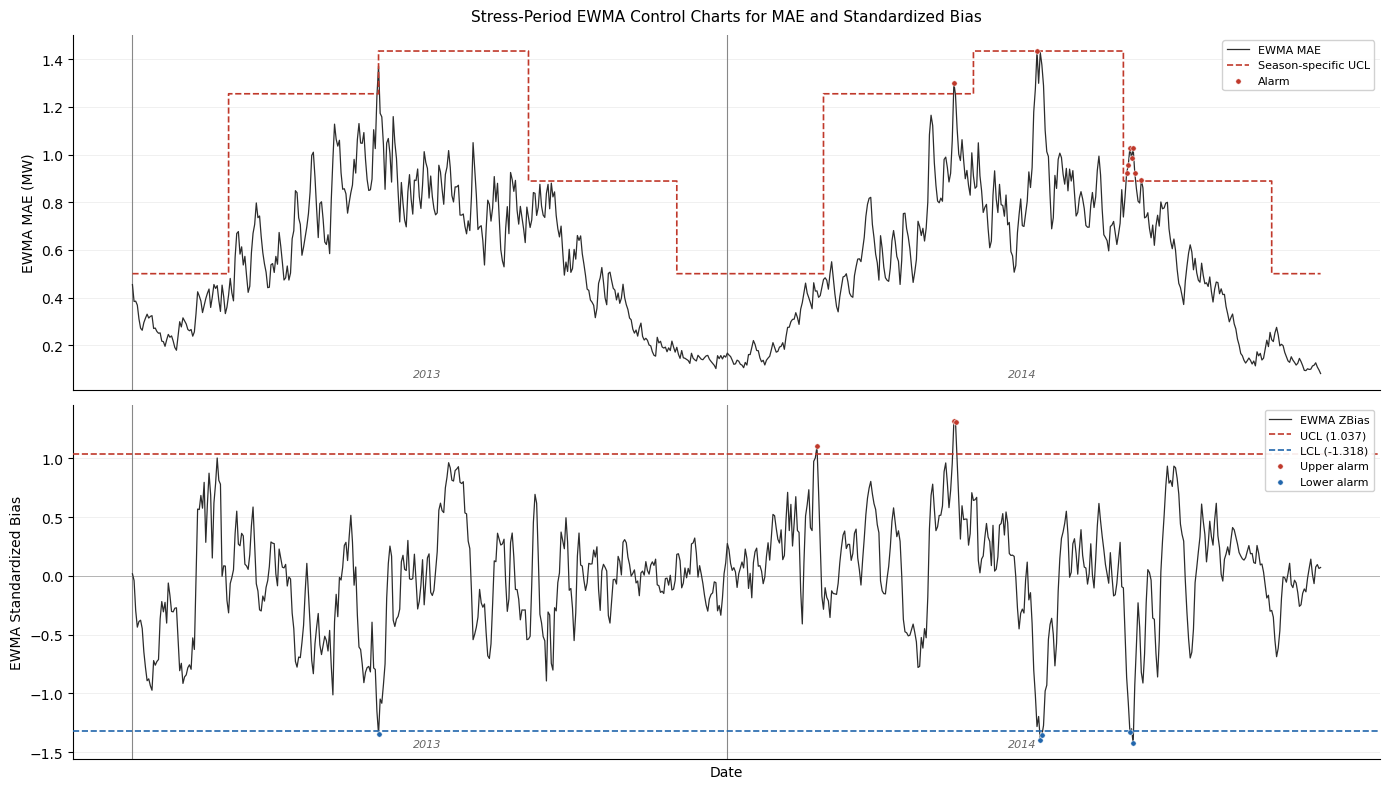

In [45]:

# =========================================================
# Stress period control charts: MAE + ZBias side by side
# =========================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Year boundaries
year_boundaries = [
    pd.Timestamp("2013-01-01"),
    pd.Timestamp("2014-01-01")
]

# =========================================================
# Panel 1: MAE chart
# =========================================================
ax1 = axes[0]

# Year boundaries
for yb in year_boundaries:
    ax1.axvline(yb, color="#888888", linewidth=0.8,
                linestyle="-", zorder=2)

# EWMA MAE
ax1.plot(
    ewma_stress_mae.index, ewma_stress_mae.values,
    color="#2c2c2c", linewidth=0.9,
    label="EWMA MAE", zorder=3
)

# Season-specific UCL
ax1.step(
    ucl_stress_mae.index, ucl_stress_mae.values,
    where="post",
    color="#c0392b", linewidth=1.2,
    linestyle="--",
    label="Season-specific UCL", zorder=3
)

# Alarm points
mae_alarm_dates = ewma_stress_mae.index[alarm_stress_mae]
mae_alarm_vals = ewma_stress_mae[alarm_stress_mae]
ax1.scatter(
    mae_alarm_dates, mae_alarm_vals,
    color="#c0392b", s=15, zorder=5,
    marker="o", edgecolors="white", linewidths=0.4,
    label="Alarm"
)

# Labels and style
ax1.set_ylabel("EWMA MAE (MW)", fontsize=10)
ax1.set_title(
    "Stress-Period EWMA Control Charts for MAE and Standardized Bias",
    fontsize=11, fontweight="normal", pad=10
)
ax1.legend(loc="upper right", fontsize=8,
           framealpha=0.9, edgecolor="#cccccc")
ax1.grid(axis="y", color="#eeeeee", linewidth=0.6, zorder=0)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# Add year labels after all elements are drawn
ymin1, ymax1 = ax1.get_ylim()
for year, xpos in [(2013, "2013-07-01"),
                   (2014, "2014-07-01")
                   ]:
    ax1.text(
        pd.Timestamp(xpos),
        ymin1 + (ymax1 - ymin1) * 0.03,
        str(year),
        fontsize=8, color="#666666",
        ha="center", va="bottom", style="italic"
    )

# =========================================================
# Panel 2: ZBias chart
# =========================================================
ax2 = axes[1]

# Year boundaries
for yb in year_boundaries:
    ax2.axvline(yb, color="#888888", linewidth=0.8,
                linestyle="-", zorder=2)

# Zero reference line
ax2.axhline(0, color="#aaaaaa", linewidth=0.6,
            linestyle="-", zorder=2)

# EWMA ZBias
ax2.plot(
    ewma_stress_zbias.index, ewma_stress_zbias.values,
    color="#2c2c2c", linewidth=0.9,
    label="EWMA ZBias", zorder=3
)

# UCL and LCL
ax2.axhline(
    ucl_zbias, color="#c0392b", linewidth=1.2,
    linestyle="--", label=f"UCL ({ucl_zbias:.3f})", zorder=3
)
ax2.axhline(
    lcl_zbias, color="#2166ac", linewidth=1.2,
    linestyle="--", label=f"LCL ({lcl_zbias:.3f})", zorder=3
)

# Upper alarms
upper_stress_dates = ewma_stress_zbias.index[alarm_stress_upper]
upper_stress_vals = ewma_stress_zbias[alarm_stress_upper]
ax2.scatter(
    upper_stress_dates, upper_stress_vals,
    color="#c0392b", s=15, zorder=5,
    marker="o", edgecolors="white", linewidths=0.4,
    label="Upper alarm"
)

# Lower alarms
lower_stress_dates = ewma_stress_zbias.index[alarm_stress_lower]
lower_stress_vals = ewma_stress_zbias[alarm_stress_lower]
ax2.scatter(
    lower_stress_dates, lower_stress_vals,
    color="#2166ac", s=15, zorder=5,
    marker="o", edgecolors="white", linewidths=0.4,
    label="Lower alarm"
)

# Labels and style
ax2.set_ylabel("EWMA Standardized Bias", fontsize=10)
ax2.set_xlabel("Date", fontsize=10)
ax2.legend(loc="upper right", fontsize=8,
           framealpha=0.9, edgecolor="#cccccc")
ax2.grid(axis="y", color="#eeeeee", linewidth=0.6, zorder=0)
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)

# Add year labels after all elements are drawn
ymin2, ymax2 = ax2.get_ylim()
for year, xpos in [(2013, "2013-07-01"),
                   (2014, "2014-07-01")
                   ]:
    ax2.text(
        pd.Timestamp(xpos),
        ymin2 + (ymax2 - ymin2) * 0.03,
        str(year),
        fontsize=8, color="#666666",
        ha="center", va="bottom", style="italic"
    )

# =========================================================
# Shared x-axis
# =========================================================
ax2.set_xticks([])

plt.tight_layout()
plt.savefig("stress_test_chart_clean.pdf", dpi=300, bbox_inches="tight")
plt.savefig("stress_test_chart_clean.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
# =========================================================
# A. 2013 ZBias representative upper-side cluster
# =========================================================
#  2013-03  2013-05  Bias、EWMA_ZBias and alarms aligned together for inspection

cluster_2013 = alarm_df_stress.loc["2013-03-01":"2013-05-31", [
    "EWMA_ZBias", "Alarm_Upper", "Alarm_Lower", "Alarm_ZBias"
]].copy()

cluster_2013["Bias_raw"] = stress_bias.loc["2013-03-01":"2013-05-31"]

print("=" * 80)
print("2013 representative ZBias cluster (March–May 2013)")
print("=" * 80)
print(cluster_2013)

#  upper alarms
cluster_2013_upper = cluster_2013[cluster_2013["Alarm_Upper"]].copy()

print("\n" + "=" * 80)
print("2013 upper-side ZBias alarms only")
print("=" * 80)
print(cluster_2013_upper)

# =========================================================
# B. Phase I MAE alarms ranked by marginal exceedance
# =========================================================
# excess = EWMA_MAE - UCL，most negative excess = most marginal alarm

phase1_mae_alarms = alarm_df_A[alarm_df_A["Alarm"] == True].copy()
phase1_mae_alarms["excess"] = (
    phase1_mae_alarms["EWMA_MAE"] - phase1_mae_alarms["UCL"]
)

print("\n" + "=" * 80)
print("Phase I MAE alarms ranked by exceedance size")
print("=" * 80)
print(
    phase1_mae_alarms[["EWMA_MAE", "UCL", "Season", "excess"]]
    .sort_values("excess")
)

# =========================================================
# C. Inspect the most marginal Phase I MAE alarm
# =========================================================
#  5 day original MAE

edge_date = phase1_mae_alarms.sort_values("excess").index[0]

print("\n" + "=" * 80)
print(f"Most marginal Phase I MAE alarm: {edge_date}")
print("=" * 80)

# alarm details
print(phase1_mae_alarms.loc[[edge_date], ["EWMA_MAE", "UCL", "Season", "excess"]])

# window around the alarm date
window = 5
mae_window = daily_mae.loc[
    edge_date - pd.Timedelta(days=window) : edge_date + pd.Timedelta(days=window)
].copy()

print("\nOriginal MAE window around the most marginal alarm")
print(mae_window)

# =========================================================
# D. Optional: inspect the top 3 most marginal alarms
# =========================================================

top3_edge_dates = phase1_mae_alarms.sort_values("excess").index[:3]

for dt in top3_edge_dates:
    print("\n" + "=" * 80)
    print(f"MAE window around marginal alarm: {dt}")
    print("=" * 80)
    print(
        phase1_mae_alarms.loc[[dt], ["EWMA_MAE", "UCL", "Season", "excess"]]
    )
    print(
        daily_mae.loc[
            dt - pd.Timedelta(days=window) : dt + pd.Timedelta(days=window)
        ]
    )

2013 representative ZBias cluster (March–May 2013)
            EWMA_ZBias  Alarm_Upper  Alarm_Lower  Alarm_ZBias  Bias_raw
2013-03-01      -0.314        False        False        False    -0.614
2013-03-02      -0.064        False        False        False     0.758
2013-03-03      -0.013        False        False        False     0.148
2013-03-04       0.053        False        False        False     0.250
2013-03-05       0.361        False        False        False     1.301
...                ...          ...          ...          ...       ...
2013-05-27      -0.816        False        False        False    -0.833
2013-05-28      -0.394        False        False        False     1.057
2013-05-29      -0.783        False        False        False    -1.931
2013-05-30      -0.795        False        False        False    -0.703
2013-05-31      -1.151        False        False        False    -2.121

[92 rows x 5 columns]

2013 upper-side ZBias alarms only
Empty DataFrame
Columns: [E

In [47]:
# =========================================================
# sensitivity analysis function for MAE and ZBias schemes
# =========================================================

def run_mae_scheme(lam, block_length, B=5000, seed=42, quantile=0.995):

    # ── Phase I calibration ──
    ucl, _, _ = mbb_by_season_ucl(
        series=phase1_mae.values,
        seasons=phase1_season.values,
        lam=lam, init=init_mae,
        block_length=block_length,
        B=B, quantile=quantile, seed=seed
    )

    # ── Phase I alarms ──
    ewma_p1  = compute_ewma(phase1_mae.values, lam, init_mae)
    ucl_p1   = phase1_season.map(ucl).to_numpy()
    alarm_p1 = ewma_p1 > ucl_p1
    rate_p1  = alarm_p1.mean()

    # ── Phase II alarms (full calendar) ──
    ewma_full_arr  = compute_ewma(full_mae.values, lam, init_mae)
    ucl_full_arr   = full_season.map(ucl).to_numpy()
    alarm_full_arr = ewma_full_arr > ucl_full_arr

    phase2_mask = (full_mae.index >= pd.Timestamp("2025-01-01"))
    rate_p2     = alarm_full_arr[phase2_mask].mean()

    # representative event checks
    def check_event(index, arr, date_str):
        dt = pd.Timestamp(date_str)
        if dt in index:
            return bool(arr[index.get_loc(dt)])
        return np.nan

    event_2014_11_24 = check_event(
        full_mae.index, alarm_full_arr, "2014-11-24")
    event_2015_05_02 = check_event(
        full_mae.index, alarm_full_arr, "2015-05-02")

    # ── Stress alarms ──
    ewma_stress  = compute_ewma(stress_mae.values, lam, init_mae)
    ucl_stress   = stress_season.map(ucl).to_numpy()
    alarm_stress = ewma_stress > ucl_stress
    rate_stress  = alarm_stress.mean()

    return {
        "UCL_Winter":        round(ucl.get("Winter", np.nan), 1),
        "UCL_Spring":        round(ucl.get("Spring", np.nan), 1),
        "UCL_Summer":        round(ucl.get("Summer", np.nan), 1),
        "UCL_Autumn":        round(ucl.get("Autumn", np.nan), 1),
        "PhaseI_rate":       round(rate_p1   * 100, 2),
        "PhaseII_rate":      round(rate_p2   * 100, 2),
        "Stress_rate":       round(rate_stress * 100, 2),
        "Event_2024_11_24":  event_2014_11_24,
        "Event_2025_05_02":  event_2015_05_02,
    }


def run_zbias_scheme(lam, block_length, B=5000, seed=42,
                     upper_q=0.995, lower_q=0.005):

    # ── Phase I calibration ──
    ucl, lcl, _ = mbb_global_common_limits(
        series=phase1_zbias.values,
        lam=lam, init=0.0,
        block_length=block_length,
        B=B, upper_q=upper_q, lower_q=lower_q, seed=seed
    )

    # ── Phase I alarms ──
    ewma_p1  = compute_ewma(phase1_zbias.values, lam, 0.0)
    alarm_p1 = (ewma_p1 > ucl) | (ewma_p1 < lcl)
    rate_p1  = alarm_p1.mean()

    # ── Phase II alarms ──
    ewma_full_z  = compute_ewma(full_zbias.values, lam, 0.0)
    alarm_full_z = (ewma_full_z > ucl) | (ewma_full_z < lcl)
    phase2_mask  = (full_zbias.index >= pd.Timestamp("2025-01-01"))
    rate_p2      = alarm_full_z[phase2_mask].mean()

    # representative event checks
    def check_event(index, arr, date_str):
        dt = pd.Timestamp(date_str)
        if dt in index:
            return bool(arr[index.get_loc(dt)])
        return np.nan

    event_2015_09_07 = check_event(
        full_zbias.index, alarm_full_z, "2015-09-07")

    # ── Stress alarms ──
    ewma_stress_z  = compute_ewma(stress_zbias.values, lam, 0.0)
    alarm_stress_z = (ewma_stress_z > ucl) | (ewma_stress_z < lcl)
    rate_stress    = alarm_stress_z.mean()

    event_2013_03_04 = check_event(
        stress_zbias.index, alarm_stress_z, "2013-03-04")

    return {
        "UCL":               round(ucl, 4),
        "LCL":               round(lcl, 4),
        "PhaseI_rate":       round(rate_p1   * 100, 2),
        "PhaseII_rate":      round(rate_p2   * 100, 2),
        "Stress_rate":       round(rate_stress * 100, 2),
        "Event_2015_09_07":  event_2015_09_07,
        "Event_2013_03_04":  event_2013_03_04,
    }


# =========================================================
# Round 1: λ sensitivity (block_length=21)
# =========================================================
print("=" * 70)
print("Round 1: λ sensitivity  (block_length = 21)")
print("=" * 70)

lam_grid = [0.1, 0.2, 0.3]
mae_results_lam   = {}
zbias_results_lam = {}

for lam in lam_grid:
    print(f"  Running λ = {lam} ...")
    mae_results_lam[lam]   = run_mae_scheme(lam,   block_length=21)
    zbias_results_lam[lam] = run_zbias_scheme(lam, block_length=21)

mae_lam_df   = pd.DataFrame(mae_results_lam).T
zbias_lam_df = pd.DataFrame(zbias_results_lam).T
mae_lam_df.index.name   = "lambda"
zbias_lam_df.index.name = "lambda"

print("\nMAE chart — λ sensitivity")
print(mae_lam_df.to_string())
print("\nZBias chart — λ sensitivity")
print(zbias_lam_df.to_string())

# =========================================================
# Round 2: block length sensitivity (λ=0.2)
# =========================================================
print("\n" + "=" * 70)
print("Round 2: block length sensitivity  (λ = 0.2)")
print("=" * 70)

bl_grid = [7, 14, 21]
mae_results_bl   = {}
zbias_results_bl = {}

for bl in bl_grid:
    print(f"  Running block_length = {bl} ...")
    mae_results_bl[bl]   = run_mae_scheme(lam=0.2,   block_length=bl)
    zbias_results_bl[bl] = run_zbias_scheme(lam=0.2, block_length=bl)

mae_bl_df   = pd.DataFrame(mae_results_bl).T
zbias_bl_df = pd.DataFrame(zbias_results_bl).T
mae_bl_df.index.name   = "block_length"
zbias_bl_df.index.name = "block_length"

print("\nMAE chart — block length sensitivity")
print(mae_bl_df.to_string())
print("\nZBias chart — block length sensitivity")
print(zbias_bl_df.to_string())

Round 1: λ sensitivity  (block_length = 21)
  Running λ = 0.1 ...
  Running λ = 0.2 ...
  Running λ = 0.3 ...

MAE chart — λ sensitivity
       UCL_Winter UCL_Spring UCL_Summer UCL_Autumn PhaseI_rate PhaseII_rate Stress_rate Event_2024_11_24 Event_2025_05_02
lambda                                                                                                                   
0.100       0.500      1.100      1.200      0.800       2.880          NaN       2.880            False            False
0.200       0.500      1.300      1.400      0.900       1.230          NaN       1.230            False            False
0.300       0.500      1.400      1.600      1.000       0.820          NaN       0.820            False            False

ZBias chart — λ sensitivity
         UCL    LCL PhaseI_rate PhaseII_rate Stress_rate Event_2015_09_07 Event_2013_03_04
lambda                                                                                    
0.100  0.793 -0.904       0.960          N